<a href="https://colab.research.google.com/github/akashchand91/InterpretingLatentReasoningInCODI/blob/main/steer_to_half_concepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# steer_to_half_concepts: what carries "×k → ×½" in CODI, and can we steer with it?

Plan: `steer-to-half-diffmean-pca-plan.md` (project). Previous run: `steer-to-half-design.md`. Lens-direction swaps did
nothing, but the **oracle** (copy the real `half`-prompt residual in at the word position) flips the answer at L3/L5/L6.
This notebook works from the **real difference vectors** `d = h_half − h_word` rather than token-derived directions.
It covers the prompt pass **and the 6 CODI latent steps**.

**Order: describe first, steer last.**

| § | cell(s) | what |
|---|---|---|
| 0 | `config` … `oracle_map` | templates T1–T4 × 9 multiplier words (1-token and 2-token families) × X. Tokenizer gate, clean-accuracy gate, capture of every (step, layer) residual, the `h + d_i == oracle` gate, and the **latent oracle map** (which (step, layer) cells are causal) |
| 1 | `diffs`, `pca`, `geometry`, `angles` | difference vectors, shared fraction, PCA + metadata labels, geometry of the multiplier words, principal angles |
| 2 | `lens_decode` | standard logit lens + J-lens readouts of d̄, d̄_op, PCs, the geometry axis and the old lens direction (both signs), plus probe-token ranks |
| 3 | `jspace` | J-space dictionary, sparse decomposition vs random baseline, and an overlap table with the concepts from §1–2 |
| 4 | `candidates` | candidate concept directions assembled from §1–3, plus controls |
| 5 | `steer`, `subspace`, `steer_plots` | one causal sweep over every candidate, and subspace sufficiency/necessity |
| – | `export` | CSVs, figures, auto-summary, W&B artifacts |

**Metrics.**
- `m̂ = (answer − X)/X`, the implied multiplier. It is target-free: 2, 3 or 4 means unchanged, 0.5 means half, ⅓ means a third.
- `acc_tgt`: whether the answer equals the half-side prompt's own answer, which is checked by the gate.
- `dLD` (nats): the change in `log p(target) − log p(source)` vs the unpatched run.

**Families.**
- The difference method needs the two prompts aligned token by token, so pairs only form **within a token-count
  family**: F1 = 1-token words (twice/triple/double vs half), F2 = 2-token words (two/three/four times vs one half / a third).
- The tokenizer gate in `tokens` assigns each word to its family from the real tokenizer.
- The read/patch position is the **last** word token.

**Fitting vs held out.**
- Directions are fit on **train X** (every other X) for the FIT words (twice, triple).
- Everything is evaluated on **held-out X**, on the held-out words (double and the F2 words), and on a leave-one-template-out variant of d̄_op.

In [ ]:
# cell: install
%pip install -q -U torchao wandb
%pip install -q git+https://github.com/anthropics/jacobian-lens.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.45.0 which is incompatible.
google-adk 2.7.1 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.45.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadat

In [ ]:
# cell: setup_colab
import os
SMOKE = globals().get('SMOKE', False)
if not SMOKE:
    from huggingface_hub import notebook_login
    notebook_login()
    from google.colab import drive
    drive.mount('/content/drive')
    JLENS_DIR = '/content/drive/MyDrive/jlens_checkpoints/codi_llama3.2-1b/compare'
    try:
        from google.colab import userdata
        os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
    except Exception as e:
        print('No Colab secret WANDB_API_KEY; falling back to interactive login:', repr(e))
    import wandb
    wandb.login()
else:
    JLENS_DIR = SMOKE_ENV['JLENS_DIR']
OUT_DIR = f'{JLENS_DIR}/steer_to_half/concepts'
FIG_DIR = f'{OUT_DIR}/figs'
os.makedirs(FIG_DIR, exist_ok=True)
print('outputs ->', OUT_DIR)

Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: akash-chand6891 (akash-chand6891-amazon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


outputs -> /content/drive/MyDrive/jlens_checkpoints/codi_llama3.2-1b/compare/steer_to_half/concepts


In [ ]:
# cell: model
import torch, torch.nn as nn, torch.nn.functional as F
import copy, re, time, json, pickle, collections, itertools, random
import numpy as np, pandas as pd

if not SMOKE:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import LoraConfig, TaskType, get_peft_model
    from huggingface_hub import hf_hub_download

    model_name = "meta-llama/Llama-3.2-1B-Instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    base_model = AutoModelForCausalLM.from_pretrained(model_name, use_safetensors=True)
    ori_vocab_size = base_model.config.vocab_size
    base_model.resize_token_embeddings(ori_vocab_size + 3)
    lora_config = LoraConfig(task_type=TaskType.CAUSAL_LM, inference_mode=False, r=128, lora_alpha=32, lora_dropout=0.1,
                             target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
                             init_lora_weights=True)
    peft_model = get_peft_model(base_model, lora_config)
    local_path = hf_hub_download(repo_id="zen-E/CODI-llama3.2-1b-Instruct", filename="pytorch_model.bin")
    sd = torch.load(local_path, map_location="cuda")
    codi_sd = {k[len("codi."):]: v for k, v in sd.items() if k.startswith("codi.")}
    missing, unexpected = peft_model.load_state_dict(codi_sd, strict=False)
    print("missing:", missing, "| unexpected:", unexpected)
    assert torch.cuda.is_available(), 'No GPU: Runtime > Change runtime type > A100 GPU'
    model = peft_model.merge_and_unload().eval().to(torch.float32).to("cuda")

    dim = model.config.hidden_size
    prj_dim = sd["prj.1.weight"].shape[0]
    prj = nn.Sequential(nn.Dropout(0.0), nn.Linear(dim, prj_dim), nn.GELU(), nn.Linear(prj_dim, dim))
    if any(k.startswith("prj.ln") for k in sd):
        prj.add_module("ln", nn.LayerNorm(dim))
    print("prj:", prj.load_state_dict({k[len("prj."):]: v for k, v in sd.items() if k.startswith("prj.")}, strict=True))
    prj = prj.to(device=model.device, dtype=model.dtype).eval()
else:
    model, tokenizer, prj, ori_vocab_size = (SMOKE_ENV[k] for k in ('model', 'tokenizer', 'prj', 'ori_vocab_size'))
    model_name = 'smoke'

bot_id = ori_vocab_size + 1
eot_id = ori_vocab_size + 2
NUM_LATENT = 6

torch.set_grad_enabled(False)  # inference only; the one autograd check (G5) re-enables it locally
torch.backends.cuda.matmul.allow_tf32 = False; torch.backends.cudnn.allow_tf32 = False
model.eval(); prj.eval()

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

...

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 3.41GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

missing: [] | unexpected: []
prj: <All keys matched successfully>


Sequential(
  (0): Dropout(p=0.0, inplace=False)
  (1): Linear(in_features=2048, out_features=2048, bias=True)
  (2): GELU(approximate='none')
  (3): Linear(in_features=2048, out_features=2048, bias=True)
  (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
)

In [ ]:
# cell: config
from fractions import Fraction
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
SOURCE_LAYERS = [3, 5, 6, 8, 9, 11, 12, 14]  # block-l output; must match the fitted lenses
STEPS = list(range(0, NUM_LATENT + 1))  # 0 = prompt pass (word position), 1..6 = latent steps (latent token)

TEMPLATES = {
    'T1': "Natalia sold clips to {X} of her friends in April, and then she sold {W} as many clips in May. How many clips did Natalia sell altogether in April and May?",
    'T2': "Tom read {X} pages on Monday, and then he read {W} as many pages on Tuesday. How many pages did Tom read altogether on Monday and Tuesday?",
    'T3': "A farm had {X} cows in spring, and then it had {W} as many cows in summer. How many cows did the farm have altogether in spring and summer?",
    'T4': "Sara baked {X} cookies on Saturday, and then she baked {W} as many cookies on Sunday. How many cookies did Sara bake altogether on Saturday and Sunday?",
}
# multiplier word -> factor m (answer = X + m*X). Leading space: the word follows 'sold ' / 'read ' / ...
MULT_WORDS = {' twice': Fraction(2), ' triple': Fraction(3), ' double': Fraction(2),
              ' two times': Fraction(2), ' three times': Fraction(3), ' four times': Fraction(4)}
HALF_WORDS = {' half': Fraction(1, 2), ' one half': Fraction(1, 2), ' a third': Fraction(1, 3)}
FACTOR = {**MULT_WORDS, **HALF_WORDS}
FIT_WORDS = [' twice', ' triple']  # d̄_op / PCs used as steering candidates are fit on these only; the rest are held-out words
X_ALL = list(range(10, 100, 2))  # even -> X/2 integer; 2-digit -> 1 token; max answer 5*98=490 -> 1 token
X_TRAIN, X_TEST = X_ALL[0::2], X_ALL[1::2]

LENS_IDS = ['identity', 'A', 'B', 'C_p', 'D_p']
LENS_ART = {'A': ('lens-A_wiki_plain', 'A_wiki_plain.pt'), 'B': ('lens-B_tmpl_plain', 'B_tmpl_plain.pt'),
            'C_p': ('lens-C_fb', 'C_fb.pt'), 'D_p': ('lens-D_fb', 'D_fb.pt')}
LENS_SOURCE = 'wandb'  # 'wandb' (falls back to Drive on failure) or 'drive'
WANDB_PROJECT, WANDB_ENTITY = 'codi-jlens-compare', None
LENS_CACHE = '/content/lenses'

MAX_NEW = 12  # greedy answer length
MAX_BATCH = 64
REQUIRE_CORRECT = True  # drop X where the clean prompt (either side of a pair) is answered wrongly
MIN_CLEAN_ACC = 0.8  # drop a (template, word) whose clean accuracy is below this
N_LATENT_CELLS = 3  # top latent (step>=1, layer) cells from the oracle map carried into §1-§5
PROMPT_LAYERS = [3, 5, 6]  # step-0 analysis layers (where the step-0 oracle flipped the answer last run)
PROMPT_STEER_LAYERS = [3, 5, 6, 8, 9]  # step-0 steering layers (8, 9 = expected-negative check)
N_PCS = 20
ALPHAS = [0.5, 1.0, 1.5, 2.0]  # steer: h + alpha * ||d_i|| * v_hat
SUBSPACE_KS = [1, 2, 3, 5, 10, 20, 50]
JSPACE_K = 25
N_RAND_CTRL = 7
TOP_N = 20  # tokens shown per lens readout
PROBES = [' half', ' twice', ' triple', ' double', ' third', ' quarter', ' times', ' multiply', ' divide', ' divided',
          ' less', ' fewer', ' more', '½', '0.5', '2', '3', '4']
HALF_CONCEPT = {'half', 'halves', 'halved', 'halving', 'divide', 'divided', 'division', 'third', 'thirds', 'quarter',
                'less', 'fewer', 'smaller', 'fraction'}  # atoms that name the 'x½' concept (J-space candidate)
SAVE_CAPTURE_ARTIFACT = True  # upload the captured residuals (fp16) to W&B
globals().update(globals().get('SMOKE_CFG', {}))  # tiny-model overrides (empty in a real run)
print('templates', list(TEMPLATES), '| words', [w.strip() for w in FACTOR], '| X', len(X_ALL), f'(train {len(X_TRAIN)}, test {len(X_TEST)})')

templates ['T1', 'T2', 'T3', 'T4'] | words ['twice', 'triple', 'double', 'two times', 'three times', 'four times', 'half', 'one half', 'a third'] | X 45 (train 23, test 22)


In [ ]:
# cell: lenses
import jlens
from jlens import JacobianLens
from jlens.vis import _meaningful_token_mask

dev = next(model.parameters()).device
bb = model.model if hasattr(model.model, 'layers') else model.model.model
embed = model.get_input_embeddings()
D = model.config.hidden_size

wandb_run, LENS_PROV, paths = None, {}, {}
if LENS_SOURCE == 'wandb':
    try:
        import wandb
        wandb_run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, job_type='concepts', name='steer_to_half_concepts')
        for k, (art_name, fname) in LENS_ART.items():
            art = wandb_run.use_artifact(f'{art_name}:latest')
            paths[k] = art.get_entry(fname).download(root=f'{LENS_CACHE}/{art_name}')
            LENS_PROV[k] = f'wandb:{art_name}:{art.version}'
    except Exception as e:
        print('W&B lens fetch failed, falling back to Drive:', repr(e))
        paths, LENS_PROV = {}, {}
        if wandb_run is not None:
            wandb_run.finish(); wandb_run = None
if not paths:
    paths = {k: f'{JLENS_DIR}/{fname}' for k, (_, fname) in LENS_ART.items()}
    LENS_PROV = {k: 'drive' for k in paths}
missing = [p for p in paths.values() if not os.path.exists(p)]
assert not missing, 'missing lens files:\n' + '\n'.join(missing)
LENSES = {k: JacobianLens.load(p) for k, p in paths.items()}
print('lens sources:', LENS_PROV)
for k, ln in LENSES.items():
    assert set(SOURCE_LAYERS) <= set(ln.source_layers), (k, ln.source_layers)

GAIN = bb.norm.weight.detach().float()
W_U = model.lm_head.weight.detach().float()  # [V, D]
V = W_U.shape[0]
WORD_MASK = _meaningful_token_mask(tokenizer, V, dev)
_J_CACHE = {}
def J(lens, L):
    """Jacobian of lens at layer L (identity lens -> None, meaning J = I). transport(h) = J @ h."""
    if lens == 'identity':
        return None
    if (lens, L) not in _J_CACHE:
        _J_CACHE[(lens, L)] = LENSES[lens].jacobians[L].to(dev).float()
    return _J_CACHE[(lens, L)]

def readout(v, lens, L):
    """Logits a residual-space DIRECTION v [D] writes under this lens: W_U (g ⊙ J_L v). No final-norm rescaling
    (v is a difference/direction, not a residual)."""
    Jl = J(lens, L)
    t = v.to(dev).float() if Jl is None else Jl @ v.to(dev).float()
    return W_U @ (GAIN * t)

def token_dir(tok_id, lens, L):
    """Residual-space direction whose lens readout is token tok_id: normalize(c_t^T J_L), c_t = g ⊙ W_U[t]."""
    c = GAIN * W_U[tok_id]
    Jl = J(lens, L)
    return F.normalize(c if Jl is None else c @ Jl, dim=0)
print('lenses ready | vocab', V, '| meaningful tokens', int(WORD_MASK.sum()))

lens sources: {'A': 'wandb:lens-A_wiki_plain:v0', 'B': 'wandb:lens-B_tmpl_plain:v0', 'C_p': 'wandb:lens-C_fb:v0', 'D_p': 'wandb:lens-D_fb:v0'}
lenses ready | vocab 128259 | meaningful tokens 99864


In [ ]:
# cell: tokens
# [§0 tokenizer gate] Each word's real token count sets its family. Pairs form only within a family (equal token
# counts -> the two prompts align token-for-token). Words whose split differs from the F1/F2 design are reported.
def toks(s):
    return tokenizer.encode(s, add_special_tokens=False)

NTOK = {w: len(toks(w)) for w in FACTOR}
FAMILY = {w: f'F{n}' for w, n in NTOK.items()}
for w in FACTOR:
    print(f'{w!r:16s} -> {[tokenizer.decode([t]) for t in toks(w)]}  ({NTOK[w]} token(s), family {FAMILY[w]}, factor {FACTOR[w]})')
PAIRS = [(w, h) for w in MULT_WORDS for h in HALF_WORDS if NTOK[w] == NTOK[h]]
lonely = [w for w in FACTOR if not any(w in p for p in PAIRS)]
print('\npairs (mult -> half-side):', [(w.strip(), h.strip()) for w, h in PAIRS])
if lonely:
    print('WARNING: no same-length partner (kept for the geometry PCA only):', [w.strip() for w in lonely])
assert any(w in FIT_WORDS and h == ' half' for w, h in PAIRS), 'the FIT words must pair with " half"'
PROBE_IDS = {}
for p in PROBES:
    ids = toks(p)
    if len(ids) == 1:
        PROBE_IDS[p] = ids[0]
    else:
        print(f'probe {p!r} is {len(ids)} tokens -> dropped')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


' twice'         -> [' twice']  (1 token(s), family F1, factor 2)
' triple'        -> [' triple']  (1 token(s), family F1, factor 3)
' double'        -> [' double']  (1 token(s), family F1, factor 2)
' two times'     -> [' two', ' times']  (2 token(s), family F2, factor 2)
' three times'   -> [' three', ' times']  (2 token(s), family F2, factor 3)
' four times'    -> [' four', ' times']  (2 token(s), family F2, factor 4)
' half'          -> [' half']  (1 token(s), family F1, factor 1/2)
' one half'      -> [' one', ' half']  (2 token(s), family F2, factor 1/2)
' a third'       -> [' a', ' third']  (2 token(s), family F2, factor 1/3)

pairs (mult -> half-side): [('twice', 'half'), ('triple', 'half'), ('double', 'half'), ('two times', 'one half'), ('two times', 'a third'), ('three times', 'one half'), ('three times', 'a third'), ('four times', 'one half'), ('four times', 'a third')]
probe '0.5' is 3 tokens -> dropped


In [ ]:
# cell: prompts
def make_prompt(t, x, w):
    return TEMPLATES[t].format(X=x, W=w.strip())

def word_span(t, w):
    """Positions (BOS included) of the word's tokens in template t. Checked against the full tokenization."""
    x0 = X_ALL[0]
    full = tokenizer.encode(make_prompt(t, x0, w))
    pre = TEMPLATES[t].split('{W}')[0].format(X=x0).rstrip(' ')
    s = len(tokenizer.encode(pre))
    span = list(range(s, s + NTOK[w]))
    assert full[s:s + NTOK[w]] == toks(w), f'{t} {w!r}: word tokens not found at {span}'
    return span

def enc_batch(texts):
    rows = [torch.cat([torch.tensor(tokenizer.encode(t)), torch.tensor([bot_id])]) for t in texts]
    assert len({r.numel() for r in rows}) == 1, 'prompts in a batch must have equal token length'
    return torch.stack(rows).to(dev)

def answer(x, w):
    a = x + FACTOR[w] * x
    return int(a) if a.denominator == 1 else None

SPAN = {(t, w): word_span(t, w) for t in TEMPLATES for w in FACTOR}
IDS = {(t, w): enc_batch([make_prompt(t, x, w) for x in X_ALL]) for t in TEMPLATES for w in FACTOR}
for t in TEMPLATES:  # G3-style: paired prompts differ only inside the word span
    for w, h in PAIRS:
        assert SPAN[(t, w)] == SPAN[(t, h)], (t, w, h)
        diff = (IDS[(t, w)] != IDS[(t, h)]).any(0).nonzero().flatten().tolist()
        assert set(diff) <= set(SPAN[(t, w)]), f'{t} {w!r}/{h!r} differ outside the word span: {diff}'
RP = {k: v[-1] for k, v in SPAN.items()}  # read/patch position at step 0 = last word token
print({t: {w.strip(): SPAN[(t, w)] for w in FACTOR} for t in ['T1']})
print('example:', make_prompt('T1', 40, ' three times'))

{'T1': {'twice': [19], 'triple': [19], 'double': [19], 'two times': [19, 20], 'three times': [19, 20], 'four times': [19, 20], 'half': [19], 'one half': [19, 20], 'a third': [19, 20]}}
example: Natalia sold clips to 40 of her friends in April, and then she sold three times as many clips in May. How many clips did Natalia sell altogether in April and May?


In [ ]:
# cell: core
@torch.no_grad()
def run(ids, patches=(), cap_layers=(), cap_pos0=()):
    """Prompt pass + NUM_LATENT CODI latent steps.
    patches: iterable of (layer, step, pos, fn); fn(x[B, D]) -> x[B, D] replaces the block-`layer` output at forward call
             `step` (0 = prompt pass, 1..NUM_LATENT = latent step) and position `pos` (latent steps: pos 0).
    cap_layers / cap_pos0: record block outputs at these layers; at step 0 at positions cap_pos0, at latent steps pos 0.
    Returns (past_key_values, captures {(step, layer, pos): [B, D] float32 on CPU}, n_patches_applied)."""
    by_layer = collections.defaultdict(list)
    for (l, s, p, fn) in patches:
        by_layer[l].append((s, p, fn))
    cap, fired, last, hooks = {}, [0], {}, []
    hooks.append(bb.norm.register_forward_hook(lambda m, i, o: last.__setitem__('h', o)))
    for l in sorted(set(by_layer) | set(cap_layers)):
        counter = [0]
        def hook(mod, inp, out, l=l, counter=counter):
            h = out[0] if isinstance(out, tuple) else out
            s = counter[0]; counter[0] += 1
            mods = [(p, fn) for (ss, p, fn) in by_layer.get(l, ()) if ss == s]
            if mods:
                h = h.clone()
                for p, fn in mods:
                    h[:, p] = fn(h[:, p]); fired[0] += 1
            if l in cap_layers:
                for p in (cap_pos0 if s == 0 else [0]):
                    cap[(s, l, p)] = h[:, p].detach().float().cpu()
            if mods:
                return (h,) + tuple(out[1:]) if isinstance(out, tuple) else h
            return out
        hooks.append(bb.layers[l].register_forward_hook(hook))
    try:
        out = model(inputs_embeds=embed(ids), use_cache=True)
        pkv = out.past_key_values
        for _ in range(NUM_LATENT):
            out = model(inputs_embeds=prj(last['h'][:, -1:, :]), past_key_values=pkv, use_cache=True)
            pkv = out.past_key_values
    finally:
        for h in hooks:
            h.remove()
    return pkv, cap, fired[0]

@torch.no_grad()
def decode(pkv, B):
    pkv = copy.deepcopy(pkv)
    nxt = embed(torch.full((B, 1), eot_id, device=dev))
    toks_, first, done = [], None, torch.zeros(B, dtype=torch.bool, device=dev)
    for t in range(MAX_NEW):
        out = model(inputs_embeds=nxt, past_key_values=pkv, use_cache=True)
        pkv = out.past_key_values
        lg = out.logits[:, -1, :ori_vocab_size + 2]
        if t == 0:
            first = lg.clone()
        nid = lg.argmax(-1)
        toks_.append(nid)
        done |= (nid == tokenizer.eos_token_id)
        if bool(done.all()):
            break
        nxt = embed(nid[:, None])
    id_lists, texts = [], []
    for r in torch.stack(toks_, 1).tolist():
        if tokenizer.eos_token_id in r:
            r = r[:r.index(tokenizer.eos_token_id)]
        id_lists.append(r); texts.append(tokenizer.decode(r, skip_special_tokens=True))
    return texts, id_lists, first

@torch.no_grad()
def score(pkv, prefix, ans_tok):
    """Teacher-forced log p(answer token | latents, <eot>, prefix). ans_tok [B, 1]."""
    B = ans_tok.shape[0]
    pkv = copy.deepcopy(pkv)
    parts = [embed(torch.full((B, 1), eot_id, device=dev))]
    if len(prefix):
        parts.append(embed(torch.tensor(prefix, device=dev)[None].expand(B, -1)))
    lg = model(inputs_embeds=torch.cat(parts, 1), past_key_values=pkv, use_cache=True).logits[:, -1, :ori_vocab_size + 2]
    return F.log_softmax(lg.float(), -1).gather(-1, ans_tok).squeeze(-1).cpu().numpy()

def parse_int(text):
    nums = re.findall(r'-?\d+', text)
    return int(nums[-1]) if nums else None

_digit = {}
def consensus_prefix(id_lists):
    prefs = []
    for r in id_lists:
        di = [i for i, t in enumerate(r) if _digit.setdefault(t, any(ch.isdigit() for ch in tokenizer.decode([t])))]
        prefs.append(tuple(r[:di[-1]]) if di else None)
    valid = [q for q in prefs if q is not None]
    return list(collections.Counter(valid).most_common(1)[0][0]) if valid else []

def ans_tok(answers):
    return torch.tensor([[toks(str(a))[0]] for a in answers], device=dev)

def bucket(pred, x, m_src, m_tgt):
    if pred is None: return 'none'
    m = (pred - x) / x
    for name, val in (('target', float(m_tgt)), ('source', float(m_src)), ('x1', 1.0), ('x0', 0.0)):
        if abs(m - val) < 1e-9: return name
    return 'other'

def evaluate(ids, xs, w, h, patches=(), prefix=None):
    """Run a (possibly patched) batch of `w` prompts; score against source answer (w) and target answer (h)."""
    pkv, _, fired = run(ids, patches)
    texts, _, first = decode(pkv, ids.shape[0])
    pred = [parse_int(t) for t in texts]
    a_s, a_t = [answer(x, w) for x in xs], [answer(x, h) for x in xs]
    pf = PREFIX if prefix is None else prefix
    lp_s, lp_t = score(pkv, pf, ans_tok(a_s)), score(pkv, pf, ans_tok(a_t))
    m_hat = np.array([np.nan if p is None else (p - x) / x for p, x in zip(pred, xs)])
    return dict(texts=texts, pred=pred, first=first, lp_s=lp_s, lp_t=lp_t, m_hat=m_hat, fired=fired,
                acc_tgt=np.array([p == a for p, a in zip(pred, a_t)], float),
                buckets=[bucket(p, x, FACTOR[w], FACTOR[h]) for p, x in zip(pred, xs)])
print('core ready')

core ready


In [ ]:
# cell: capture
# [§0] One clean CODI run per (template, word) over all X: answers + residuals at every (step, layer).
# Step 0 is recorded at every word-span position; latent steps at the latent token (pos 0).
CAP, CLEAN = {}, {}
t0 = time.time()
for t in TEMPLATES:
    for w in FACTOR:
        pkv, cap, _ = run(IDS[(t, w)], cap_layers=SOURCE_LAYERS, cap_pos0=SPAN[(t, w)])
        texts, id_lists, _ = decode(pkv, len(X_ALL))
        CAP[(t, w)] = cap
        CLEAN[(t, w)] = dict(texts=texts, id_lists=id_lists, pred=[parse_int(s) for s in texts])
print(f'captured {len(CAP)} (template, word) batches in {time.time() - t0:.0f}s')
PREFIX = consensus_prefix([r for v in CLEAN.values() for r in v['id_lists']])
print('shared answer prefix:', PREFIX, '->', repr(tokenizer.decode(PREFIX)))

def resid(t, w, s, L, pos='rp'):
    """[N_X, D] residual for (template, word) at step s, layer L. Step 0: the read position (last word token) unless
    pos='first' (first word token; only differs for F2). Latent steps: the latent token."""
    if s == 0:
        p = RP[(t, w)] if pos == 'rp' else SPAN[(t, w)][0]
    else:
        p = 0
    return CAP[(t, w)][(s, L, p)]

captured 36 (template, word) batches in 21s
shared answer prefix: [791, 4320, 374, 25, 220] -> 'The answer is: '


In [ ]:
# cell: accuracy_gate
# [§0] Clean accuracy per (template, word). A word must answer X + m*X; X where m*X is not an integer are n/a.
rows = []
OK = {}
for (t, w), c in CLEAN.items():
    exp = [answer(x, w) for x in X_ALL]
    ok = np.array([e is not None and p == e for p, e in zip(c['pred'], exp)])
    applicable = np.array([e is not None for e in exp])
    OK[(t, w)] = ok if REQUIRE_CORRECT else applicable
    rows.append(dict(template=t, word=w.strip(), family=FAMILY[w], acc=ok[applicable].mean(), n=int(applicable.sum()),
                     example=c['texts'][X_ALL.index(40)] if 40 in X_ALL else c['texts'][0]))
ACC = pd.DataFrame(rows)
print(ACC.pivot_table(index='word', columns='template', values='acc').round(2).to_string())
KEEP = {(r.template, ' ' + r.word) for r in ACC.itertuples() if r.acc >= MIN_CLEAN_ACC or not REQUIRE_CORRECT}
dropped = sorted({(t, w) for (t, w) in CLEAN} - KEEP)
print('\ndropped (template, word) below MIN_CLEAN_ACC:', [(t, w.strip()) for t, w in dropped] or 'none')

# valid (template, mult word, half word) triples and the X indices usable for each (both sides answered correctly)
TRIPLES = []
for t in TEMPLATES:
    for w, h in PAIRS:
        if (t, w) in KEEP and (t, h) in KEEP:
            idx = np.where(OK[(t, w)] & OK[(t, h)])[0]
            if len(idx):
                TRIPLES.append((t, w, h, idx))
print(f'{len(TRIPLES)} valid (template, word, half-side) triples;',
      'X per triple:', {f'{t}:{w.strip()}->{h.strip()}': len(i) for t, w, h, i in TRIPLES})
TRAIN_IDX = {x: i for i, x in enumerate(X_ALL) if x in X_TRAIN}
TEST_IDX = {x: i for i, x in enumerate(X_ALL) if x in X_TEST}
def split(idx, which):
    keep = TRAIN_IDX if which == 'train' else TEST_IDX
    return np.array([i for i in idx if X_ALL[i] in keep], dtype=int)

template       T1    T2    T3    T4
word                               
a third      1.00  1.00  1.00  1.00
double       1.00  1.00  1.00  1.00
four times   0.96  0.98  0.98  0.96
half         1.00  1.00  1.00  1.00
one half     1.00  1.00  1.00  1.00
three times  1.00  1.00  1.00  1.00
triple       1.00  1.00  1.00  1.00
twice        1.00  1.00  1.00  1.00
two times    1.00  1.00  1.00  1.00

dropped (template, word) below MIN_CLEAN_ACC: none
36 valid (template, word, half-side) triples; X per triple: {'T1:twice->half': 45, 'T1:triple->half': 45, 'T1:double->half': 45, 'T1:two times->one half': 45, 'T1:two times->a third': 15, 'T1:three times->one half': 45, 'T1:three times->a third': 15, 'T1:four times->one half': 43, 'T1:four times->a third': 15, 'T2:twice->half': 45, 'T2:triple->half': 45, 'T2:double->half': 45, 'T2:two times->one half': 45, 'T2:two times->a third': 15, 'T2:three times->one half': 45, 'T2:three times->a third': 15, 'T2:four times->one half': 44, 'T2:four times->a t

GATE h + d_i == oracle at step 0 L3 (T1 twice->half): max |logit diff| 2.10e-05, preds equal True, oracle acc 1.00
oracle map: 2496 rows in 1349s

[oracle acc_tgt, mean over all triples] rows = step (0 = prompt), cols = layer
layer    3     5     6     8     9    11   12   14
step                                              
0      0.88  0.73  0.56  0.05  0.01  0.0  0.0  0.0
1      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
2      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
3      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
4      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
5      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
6      0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0

[per pair, step 0]
layer                    3     5     6     8     9    11   12   14
pair                                                              
double->half           1.00  0.99  0.95  0.16  0.04  0.0  0.0  0.0
four times->a third    0.78  0.38  0.17  0.00  0.00  0.0  0.0  0.0
four times->one half   0.79

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()


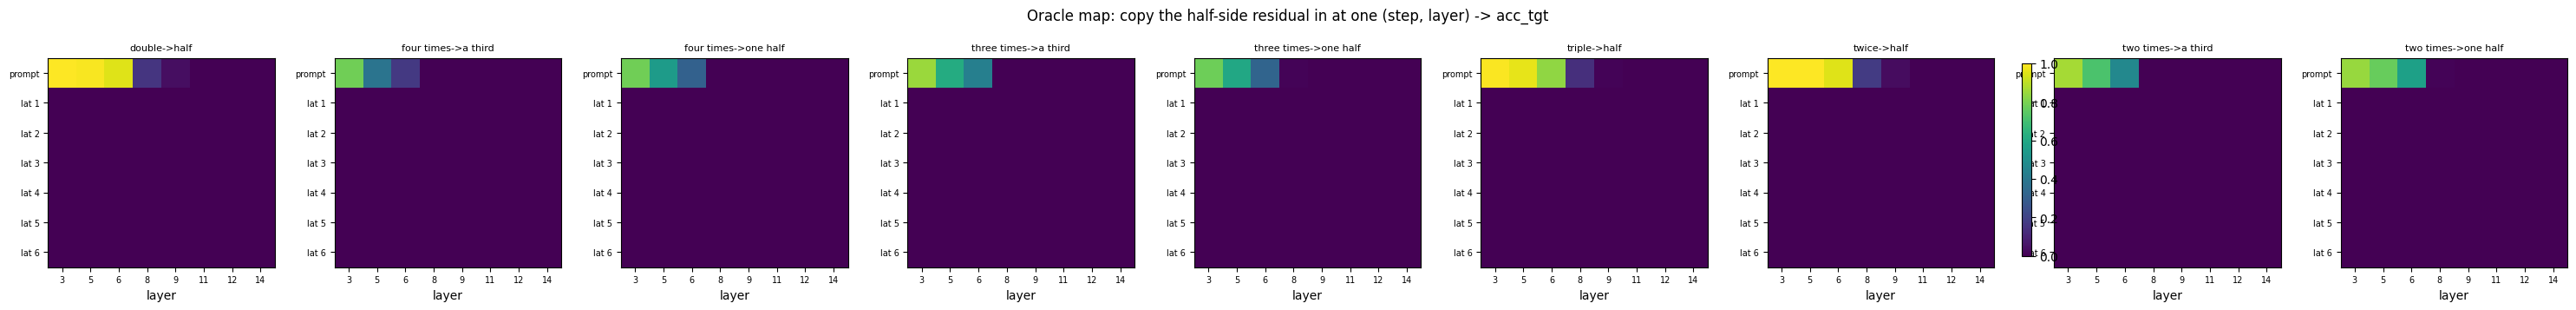

In [ ]:
# cell: oracle_map
# [§0] Gate: adding each example's own difference d_i at step 0 must reproduce the oracle (copying h_half in).
# Map: copy the half-side residual in at ONE (step, layer) cell and see if the answer flips -> which latent cells are
# causal. Also 'two_sided' per layer (prompt read position + every latent step), and for F2 at step 0 'both' (patch
# both word tokens) vs the default last token.
def repl(v):
    v = v.to(dev)
    return lambda x: v
def addv(v):
    v = v.to(dev)
    return lambda x: x + v

def save_df(df, name):
    df.to_csv(f'{OUT_DIR}/{name}.csv', index=False)
    return df

t, w, h, idx = next(tr for tr in TRIPLES if tr[1] in FIT_WORDS and tr[2] == ' half')
ids, xs = IDS[(t, w)][idx], [X_ALL[i] for i in idx]
L0 = PROMPT_LAYERS[0]
p = RP[(t, w)]
v_half = resid(t, h, 0, L0)[idx]
r_orc = evaluate(ids, xs, w, h, [(L0, 0, p, repl(v_half))])
r_add = evaluate(ids, xs, w, h, [(L0, 0, p, addv(v_half - resid(t, w, 0, L0)[idx]))])
dmax = (r_orc['first'] - r_add['first']).abs().max().item()
print(f'GATE h + d_i == oracle at step 0 L{L0} ({t} {w.strip()}->{h.strip()}): max |logit diff| {dmax:.2e},',
      f'preds equal {r_orc["pred"] == r_add["pred"]}, oracle acc {r_orc["acc_tgt"].mean():.2f}')
assert dmax < 1e-3 and r_orc['pred'] == r_add['pred'], 'h + d_i does not reproduce the oracle'
r0 = evaluate(ids, xs, w, h, [])
assert r0['fired'] == 0 and all(b == 'source' for b in r0['buckets']) or not REQUIRE_CORRECT, 'clean run not at source answer'

rows = []
t0 = time.time()
for (t, w, h, idx) in TRIPLES:
    ids, xs = IDS[(t, w)][idx], [X_ALL[i] for i in idx]
    base = evaluate(ids, xs, w, h)
    ld0 = (base['lp_t'] - base['lp_s']).mean()
    def rec(res, step, L, variant):
        rows.append(dict(template=t, word=w.strip(), half=h.strip(), pair=f'{w.strip()}->{h.strip()}', family=FAMILY[w],
                         target=str(FACTOR[h]), step=step, layer=L, variant=variant, n=len(xs),
                         acc_tgt=res['acc_tgt'].mean(), m_hat=np.nanmean(res['m_hat']),
                         dLD=(res['lp_t'] - res['lp_s']).mean() - ld0))
    for L in SOURCE_LAYERS:
        for s in STEPS:
            pos = RP[(t, w)] if s == 0 else 0
            rec(evaluate(ids, xs, w, h, [(L, s, pos, repl(resid(t, h, s, L)[idx]))]), s, L, 'single')
        if NTOK[w] > 1:
            both = [(L, 0, q, repl(CAP[(t, h)][(0, L, q)][idx])) for q in SPAN[(t, w)]]
            rec(evaluate(ids, xs, w, h, both), 0, L, 'f2_both_tokens')
        two = [(L, 0, RP[(t, w)], repl(resid(t, h, 0, L)[idx]))] + [(L, s, 0, repl(resid(t, h, s, L)[idx])) for s in STEPS[1:]]
        rec(evaluate(ids, xs, w, h, two), 'all', L, 'two_sided')
ORACLE = save_df(pd.DataFrame(rows), 'oracle_map')
print(f'oracle map: {len(ORACLE)} rows in {time.time() - t0:.0f}s')

single = ORACLE[ORACLE.variant == 'single']
tab = single.pivot_table(index='step', columns='layer', values='acc_tgt')
print('\n[oracle acc_tgt, mean over all triples] rows = step (0 = prompt), cols = layer'); print(tab.round(2).to_string())
print('\n[per pair, step 0]'); print(single[single.step == 0].pivot_table(index='pair', columns='layer', values='acc_tgt').round(2).to_string())
print('\n[two-sided per layer]'); print(ORACLE[ORACLE.variant == 'two_sided'].pivot_table(index='pair', columns='layer', values='acc_tgt').round(2).to_string())
f2 = ORACLE[ORACLE.family == 'F2']
if len(f2):
    cmp_ = f2[(f2.step == 0) & f2.variant.isin(['single', 'f2_both_tokens'])].pivot_table(index='variant', columns='layer', values='acc_tgt')
    print('\n[F2 step 0: last token vs both tokens]'); print(cmp_.round(2).to_string())

lat = single[single.step != 0].groupby(['step', 'layer']).acc_tgt.mean().sort_values(ascending=False)
LATENT_CELLS = [tuple(map(int, c)) for c in lat.index[:N_LATENT_CELLS]]
print('\nLATENT_CELLS (top latent oracle cells):', [(c, round(lat[c], 2)) for c in LATENT_CELLS],
      '' if lat.iloc[0] >= 0.5 else '  <- NOTE: no latent cell reaches 0.5; latent steps look non-causal for this operation')
ANALYSIS_CELLS = [(0, L) for L in PROMPT_LAYERS] + LATENT_CELLS

import matplotlib
if SMOKE: matplotlib.use('Agg')
import matplotlib.pyplot as plt
def savefig(fig, name):
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
pairs_ = sorted(single.pair.unique())
fig, axs = plt.subplots(1, len(pairs_), figsize=(3.2 * len(pairs_) + 1, 3.6), squeeze=False)
for ax, pr in zip(axs[0], pairs_):
    tt = single[single.pair == pr].pivot_table(index='step', columns='layer', values='acc_tgt').reindex(index=STEPS, columns=SOURCE_LAYERS)
    im = ax.imshow(tt.values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(SOURCE_LAYERS))); ax.set_xticklabels(SOURCE_LAYERS, fontsize=7)
    ax.set_yticks(range(len(STEPS))); ax.set_yticklabels(['prompt'] + [f'lat {s}' for s in STEPS[1:]], fontsize=7)
    ax.set_title(pr, fontsize=8); ax.set_xlabel('layer')
fig.colorbar(im, ax=list(axs[0]), shrink=0.8); fig.suptitle('Oracle map: copy the half-side residual in at one (step, layer) -> acc_tgt')
savefig(fig, 'oracle_map')

In [ ]:
# cell: diffs
# [§1] Difference vectors d_i = h_halfside - h_word for every valid triple, at every (step, layer). Metadata per row.
def diff_rows(s, L, which='train', triples=None):
    Ds, meta = [], []
    for (t, w, h, idx) in (triples or TRIPLES):
        ii = split(idx, which) if which in ('train', 'test') else idx
        if not len(ii):
            continue
        Ds.append(resid(t, h, s, L)[ii] - resid(t, w, s, L)[ii])
        meta += [dict(template=t, word=w.strip(), half=h.strip(), pair=f'{w.strip()}->{h.strip()}', family=FAMILY[w],
                      m=float(FACTOR[w]), target=float(FACTOR[h]), X=X_ALL[i], fit=w in FIT_WORDS and h == ' half') for i in ii]
    return (torch.cat(Ds) if Ds else torch.zeros(0, D)), pd.DataFrame(meta)

GROUPS = {'half_all': lambda m: m.target == 0.5, 'fit': lambda m: m.fit, 'F1_half': lambda m: (m.family == 'F1') & (m.target == 0.5),
          'F2_half': lambda m: (m.family == 'F2') & (m.target == 0.5), 'F2_third': lambda m: m.target == 1 / 3, 'all': lambda m: m.X > -1}

def shared_fraction(Dm):
    return (len(Dm) * Dm.mean(0).norm() ** 2 / (Dm.norm() ** 2)).item() if len(Dm) else np.nan

rows = []
for s in STEPS:
    for L in SOURCE_LAYERS:
        Dm, meta = diff_rows(s, L)
        for g, sel in GROUPS.items():
            m = sel(meta).values if len(meta) else np.zeros(0, bool)
            rows.append(dict(step=s, layer=L, group=g, n=int(m.sum()), shared=shared_fraction(Dm[torch.tensor(m)]) if m.any() else np.nan,
                             mean_norm=Dm[torch.tensor(m)].norm(dim=1).mean().item() if m.any() else np.nan))
SHARED = save_df(pd.DataFrame(rows), 'shared_fraction')
for g in ['half_all', 'fit']:
    print(f'\n[shared fraction N|d̄|²/|D|², group {g}] rows = step, cols = layer')
    print(SHARED[SHARED.group == g].pivot_table(index='step', columns='layer', values='shared').round(2).to_string())
print('\n[mean |d_i|, group half_all]'); print(SHARED[SHARED.group == 'half_all'].pivot_table(index='step', columns='layer', values='mean_norm').round(1).to_string())


[shared fraction N|d̄|²/|D|², group half_all] rows = step, cols = layer
layer    3     5     6     8     9     11    12    14
step                                                 
0      0.68  0.71  0.71  0.66  0.66  0.70  0.70  0.68
1      0.65  0.62  0.61  0.53  0.49  0.49  0.48  0.35
2      0.45  0.42  0.42  0.42  0.39  0.36  0.37  0.35
3      0.57  0.53  0.52  0.47  0.46  0.39  0.45  0.46
4      0.68  0.68  0.71  0.73  0.75  0.71  0.63  0.35
5      0.45  0.41  0.42  0.41  0.37  0.34  0.33  0.28
6      0.39  0.36  0.36  0.41  0.38  0.34  0.34  0.33

[shared fraction N|d̄|²/|D|², group fit] rows = step, cols = layer
layer    3     5     6     8     9     11    12    14
step                                                 
0      0.79  0.81  0.82  0.74  0.74  0.78  0.78  0.77
1      0.65  0.62  0.61  0.53  0.49  0.48  0.48  0.34
2      0.44  0.41  0.41  0.41  0.38  0.36  0.36  0.35
3      0.56  0.51  0.51  0.47  0.46  0.39  0.45  0.45
4      0.67  0.67  0.71  0.74  0.76  0.74  0.65  

[explained variance + how d̄ relates to the PCs]
    step  layer     group    n    ev1    ev2    ev3    ev4    ev5  ev_top5  cos_dbar_uncentred_top  cos_dbar_pc1  cos_dbar_pc2  cos_dbar_pc3
0      0      3       all  633  0.356  0.262  0.128  0.075  0.043    0.863                   0.996         0.281         0.378         0.253
1      0      3  half_all  549  0.463  0.215  0.092  0.056  0.046    0.871                   0.996         0.405         0.067         0.163
2      0      3       fit  184  0.765  0.094  0.048  0.042  0.018    0.966                   0.999         0.152         0.130         0.110
3      0      5       all  633  0.326  0.281  0.129  0.077  0.036    0.850                   0.998         0.232         0.266         0.224
4      0      5  half_all  549  0.434  0.234  0.094  0.048  0.040    0.851                   0.998         0.306         0.066         0.143
5      0      5       fit  184  0.717  0.093  0.070  0.042  0.016    0.938                   0.999       

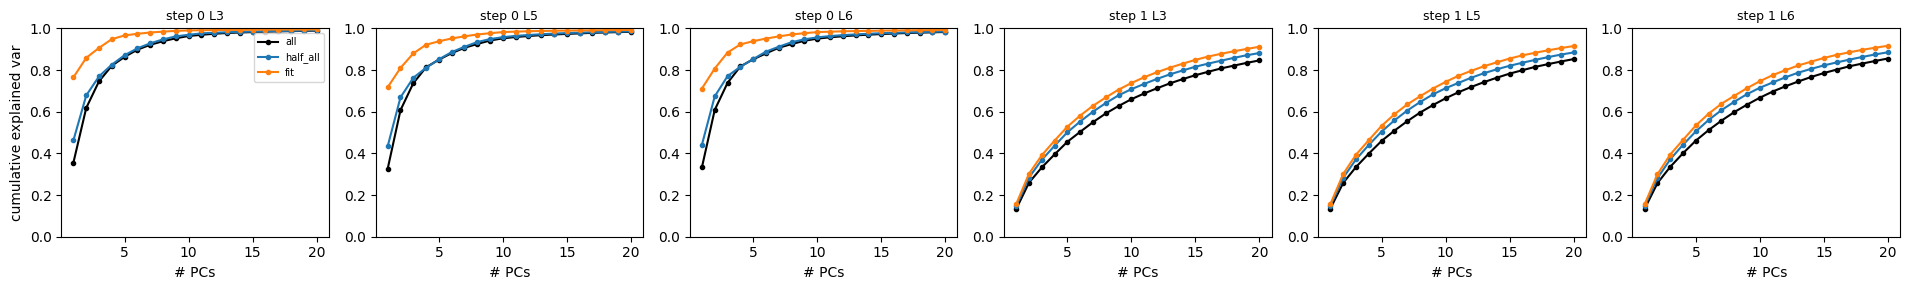

In [ ]:
# cell: pca
# [§1] Centred PCA of D - d̄ at the analysis cells; each PC labelled by its association with the metadata.
from scipy.stats import pearsonr
def eta2(score, cat):
    """Correlation ratio: fraction of the PC score's variance explained by a categorical factor."""
    df = pd.DataFrame(dict(s=score, c=cat))
    tot = ((df.s - df.s.mean()) ** 2).sum()
    return float((df.groupby('c').s.transform('mean').sub(df.s.mean()) ** 2).sum() / tot) if tot > 0 else np.nan

PCA, PC_LABELS, EXPL = {}, [], []
for cell in ANALYSIS_CELLS:
    s, L = cell
    Dm, meta = diff_rows(s, L)
    for g in ['all', 'half_all', 'fit']:
        m = torch.tensor(GROUPS[g](meta).values)
        X_ = Dm[m]; mt = meta[m.numpy()].reset_index(drop=True)
        if len(X_) < 3:
            continue
        dbar = X_.mean(0)
        U, S, Vt = torch.linalg.svd(X_ - dbar, full_matrices=False)
        ev = (S ** 2 / (S ** 2).sum()).numpy()
        _, S2, Vt2 = torch.linalg.svd(X_, full_matrices=False)  # uncentred
        k = min(N_PCS, len(ev))
        # orient each PC so d̄ projects positively (so +PC points toward the half side where it can)
        sign = torch.sign(Vt[:k] @ dbar); sign[sign == 0] = 1
        pcs = Vt[:k] * sign[:, None]
        PCA[(cell, g)] = dict(dbar=dbar, pcs=pcs, ev=ev[:k], uncentred_top=Vt2[0], meta=mt, scores=(X_ - dbar) @ pcs.T)
        EXPL.append(dict(step=s, layer=L, group=g, n=len(X_), **{f'ev{i+1}': ev[i] for i in range(min(5, k))},
                         ev_top5=ev[:5].sum(), cos_dbar_uncentred_top=abs(F.cosine_similarity(dbar, Vt2[0], dim=0).item()),
                         **{f'cos_dbar_pc{i+1}': F.cosine_similarity(dbar, pcs[i], dim=0).item() for i in range(min(3, k))}))
        if g == 'all':
            sc = PCA[(cell, g)]['scores'].numpy()
            for i in range(min(5, k)):
                r = dict(step=s, layer=L, pc=i + 1, ev=ev[i])
                for col in ['X', 'm', 'target']:
                    v = mt[col].values.astype(float)
                    r[f'r_{col}'] = pearsonr(sc[:, i], v)[0] if v.std() > 0 else np.nan
                r['r_logX'] = pearsonr(sc[:, i], np.log(mt.X.values))[0]
                for col in ['template', 'word', 'family', 'pair']:
                    r[f'eta2_{col}'] = eta2(sc[:, i], mt[col].values)
                PC_LABELS.append(r)
EXPL = save_df(pd.DataFrame(EXPL), 'pca_explained')
PC_LABELS = save_df(pd.DataFrame(PC_LABELS), 'pca_labels')
print('[explained variance + how d̄ relates to the PCs]'); print(EXPL.round(3).to_string())
print('\n[PC labels, group all: |r| numeric, eta² categorical]'); print(PC_LABELS.round(2).to_string())

fig, axs = plt.subplots(1, len(ANALYSIS_CELLS), figsize=(3.2 * len(ANALYSIS_CELLS), 3), squeeze=False)
for ax, cell in zip(axs[0], ANALYSIS_CELLS):
    for g, c in [('all', 'k'), ('half_all', 'C0'), ('fit', 'C1')]:
        if (cell, g) in PCA:
            ax.plot(np.arange(1, len(PCA[(cell, g)]['ev']) + 1), np.cumsum(PCA[(cell, g)]['ev']), marker='.', color=c, label=g)
    ax.set_title(f'step {cell[0]} L{cell[1]}', fontsize=9); ax.set_xlabel('# PCs'); ax.set_ylim(0, 1)
axs[0, 0].set_ylabel('cumulative explained var'); axs[0, 0].legend(fontsize=7)
savefig(fig, 'pca_explained')

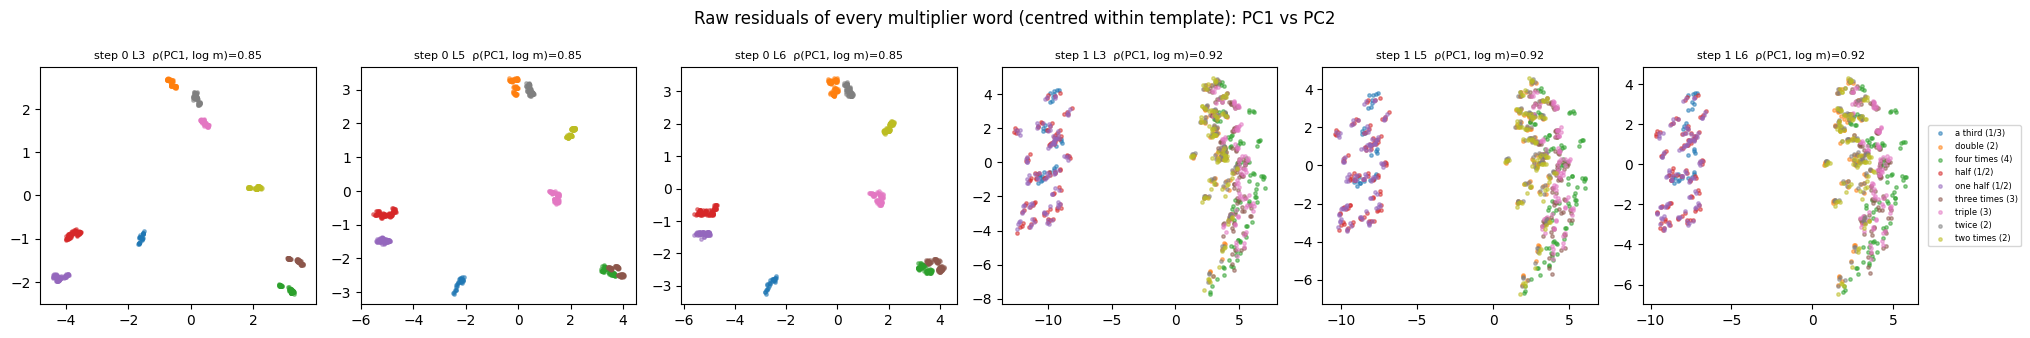

   step  layer  spearman_pc1_logfactor    ev1                                                                             order_along_pc1
0     0      3                   0.855  0.409  one half < half < a third < double < twice < triple < two times < four times < three times
1     0      5                   0.855  0.431  one half < half < a third < double < twice < triple < two times < four times < three times
2     0      6                   0.855  0.437  one half < half < a third < double < twice < triple < two times < four times < three times
3     1      3                   0.923  0.422  one half < half < a third < two times < twice < double < three times < triple < four times
4     1      5                   0.923  0.381  one half < half < a third < double < twice < two times < three times < triple < four times
5     1      6                   0.923  0.372  one half < half < a third < double < twice < two times < three times < triple < four times


In [ ]:
# cell: geometry
# [§1.4] PCA of the RAW residuals of every word (not differences), centred within template, at the analysis cells.
# Question: do the factors ⅓, ½, 2, 3, 4 line up along one axis; do synonyms land together?
from scipy.stats import spearmanr
GEOM, GEOM_ROWS = {}, []
fig, axs = plt.subplots(1, len(ANALYSIS_CELLS), figsize=(3.4 * len(ANALYSIS_CELLS), 3.4), squeeze=False)
for ax, cell in zip(axs[0], ANALYSIS_CELLS):
    s, L = cell
    Hs, meta = [], []
    for t in TEMPLATES:
        ws = [w for w in FACTOR if (t, w) in KEEP]
        Ht = [resid(t, w, s, L)[split(np.where(OK[(t, w)])[0], 'train')] for w in ws]
        mu = torch.cat(Ht).mean(0)
        for w, Hw in zip(ws, Ht):
            Hs.append(Hw - mu); meta += [dict(template=t, word=w.strip(), factor=float(FACTOR[w]), family=FAMILY[w])] * len(Hw)
    Hm, meta = torch.cat(Hs), pd.DataFrame(meta)
    _, S_, Vt_ = torch.linalg.svd(Hm - Hm.mean(0), full_matrices=False)
    sc = ((Hm - Hm.mean(0)) @ Vt_[:2].T).numpy()
    meta['pc1'], meta['pc2'] = sc[:, 0], sc[:, 1]
    cent = meta.groupby('word')[['pc1', 'pc2', 'factor']].mean()
    rho = spearmanr(cent.pc1, np.log(cent.factor))[0]
    axis = Vt_[0] if rho >= 0 else -Vt_[0]  # oriented so +axis = larger factor
    # candidate direction points toward SMALLER factor (the half side): -axis
    GEOM[cell] = dict(axis_to_half=-axis, rho=rho, centroids=cent)
    GEOM_ROWS.append(dict(step=s, layer=L, spearman_pc1_logfactor=rho, ev1=(S_[0] ** 2 / (S_ ** 2).sum()).item(),
                          order_along_pc1=' < '.join(cent.sort_values('pc1').index)))
    for wd, g in meta.groupby('word'):
        ax.scatter(g.pc1, g.pc2, s=6, alpha=0.5, label=f'{wd} ({FACTOR[" " + wd]})')
    ax.set_title(f'step {s} L{L}  ρ(PC1, log m)={rho:.2f}', fontsize=8)
axs[0, -1].legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.suptitle('Raw residuals of every multiplier word (centred within template): PC1 vs PC2')
savefig(fig, 'geometry_pc12')
GEOM_DF = save_df(pd.DataFrame(GEOM_ROWS), 'geometry')
print(GEOM_DF.round(3).to_string())

In [ ]:
# cell: angles
# [§1.5] Principal angles between top-5 difference subspaces (mean cos of the 5 angles; 1 = same subspace, ~0.1 = random).
from scipy.linalg import subspace_angles
def top_subspace(Dm, k=5):
    if len(Dm) < k + 1:
        return None
    return torch.linalg.svd(Dm - Dm.mean(0), full_matrices=False)[2][:k].T.numpy()
def mean_cos(A, B):
    return np.nan if A is None or B is None else float(np.cos(subspace_angles(A, B)).mean())

rows = []
subs = {}
for cell in ANALYSIS_CELLS:
    Dm, meta = diff_rows(*cell)
    subs[cell] = top_subspace(Dm)
    sel = lambda f: top_subspace(Dm[torch.tensor(f(meta).values)])
    r = dict(cell=str(cell), F1_vs_F2_half=mean_cos(sel(GROUPS['F1_half']), sel(GROUPS['F2_half'])),
             half_vs_third_F2=mean_cos(sel(GROUPS['F2_half']), sel(GROUPS['F2_third'])))
    for t in TEMPLATES:
        r[f'{t}_vs_rest'] = mean_cos(sel(lambda m: m.template == t), sel(lambda m: m.template != t))
    rows.append(r)
ANG = pd.DataFrame(rows)
cells_ = list(subs)
ANG_CELLS = pd.DataFrame([[mean_cos(subs[a], subs[b]) for b in cells_] for a in cells_], index=map(str, cells_), columns=map(str, cells_))
rng_ = np.random.default_rng(0)
rand_base = mean_cos(np.linalg.qr(rng_.standard_normal((D, 5)))[0], np.linalg.qr(rng_.standard_normal((D, 5)))[0])
print(f'[principal-angle mean cos; random 5-dim subspaces give ≈ {rand_base:.3f}]'); print(ANG.round(2).to_string())
print('\n[across analysis cells]'); print(ANG_CELLS.round(2).to_string())
save_df(ANG, 'principal_angles'); ANG_CELLS.to_csv(f'{OUT_DIR}/principal_angles_cells.csv')

[principal-angle mean cos; random 5-dim subspaces give ≈ 0.046]
     cell  F1_vs_F2_half  half_vs_third_F2  T1_vs_rest  T2_vs_rest  T3_vs_rest  T4_vs_rest
0  (0, 3)           0.39              0.76        0.87        0.92        0.93        0.87
1  (0, 5)           0.47              0.72        0.80        0.82        0.92        0.83
2  (0, 6)           0.47              0.71        0.80        0.80        0.77        0.82
3  (1, 3)           0.96              0.44        0.99        1.00        0.99        1.00
4  (1, 5)           0.96              0.45        0.99        1.00        0.99        1.00
5  (1, 6)           0.96              0.45        0.99        1.00        0.99        1.00

[across analysis cells]
        (0, 3)  (0, 5)  (0, 6)  (1, 3)  (1, 5)  (1, 6)
(0, 3)    1.00    0.73    0.65    0.15    0.14    0.14
(0, 5)    0.73    1.00    0.90    0.13    0.13    0.13
(0, 6)    0.65    0.90    1.00    0.13    0.13    0.13
(1, 3)    0.15    0.13    0.13    1.00    0.97    0.95


==== step 0 L3: top-20 tokens (+ = pushed up, - = pushed down) ====
d_op   identity +   half  Half  hal  HALF half  part Half  halfway  halves  Quarter  salv 半  полу  bre  sf  fraction  mili  mand  portion portion
d_op   identity -   triple Triple  Triple  triples iple مر بير 倍  Multiple oppel Multiple  Opportunity  multiple  Trilogy apphire  Twice 려 ンパ  multiplier оров
d_op   A        +   half  Half  halfway  HALF  halves Half  portion half  полу  quarter  roughly  semi ½  halftime  半  nửa  part rolls  bits  mixture
d_op   A        -  Multiple  triple  Multiple  triplet  Conway een ultiple Multi  Tk multiple  duplicated Dyn สว pty  multiple Triple  Twice  Crowley  Cv ooke
d_op   B        +  ih  half orus ucus  halfway  sweat  mildly  Strip ifth alf  strip aching ung  Half irus ollow Controls Half isko ached
d_op   B        -  pez arges  Cheney вати  Trey vely pty  rede  rv  retirement layers ecial udic  près former  Conway kre bles 昌 gere
d_op   C_p      +  icha hattan  sf  gel  Gel 

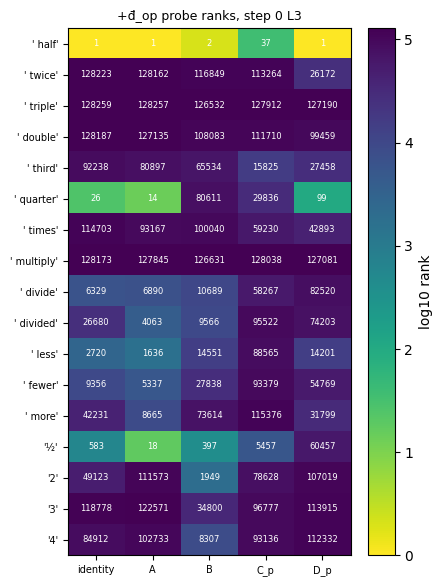

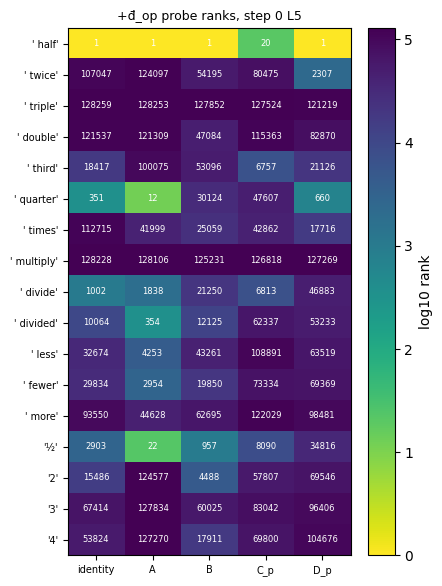

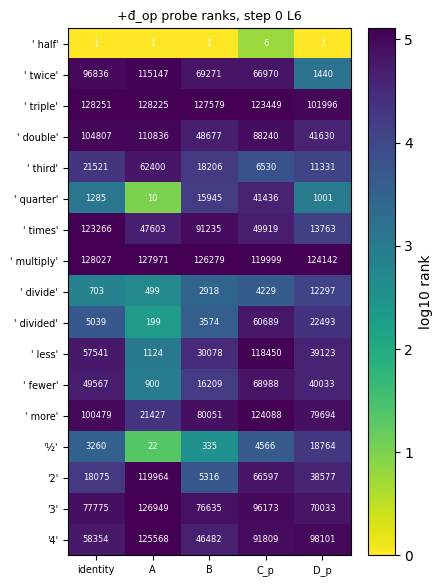

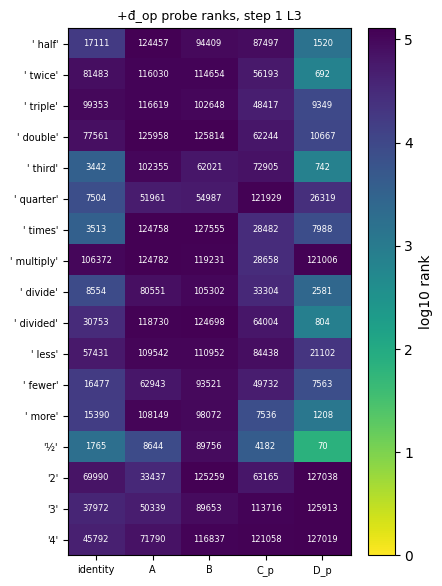

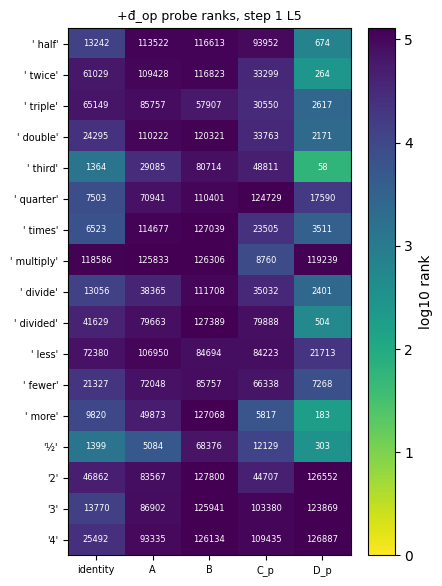

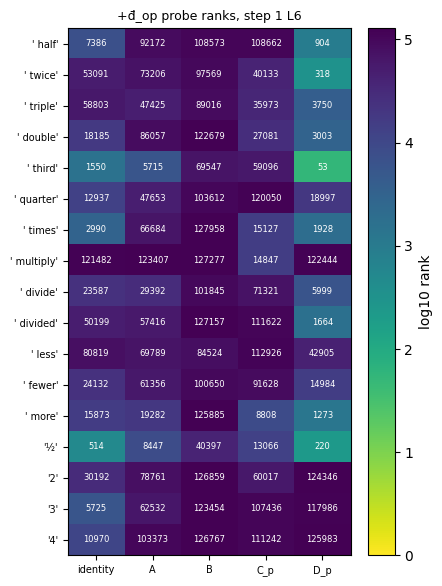

In [ ]:
# cell: lens_decode
# [§2] Standard logit lens (identity) and J-lens readouts of the directions, both signs. Top/bottom tokens restricted to
# meaningful tokens; probe tokens ranked over the full vocab (1 = top).
def directions_at(cell):
    s, L = cell
    out = {}
    Dm, meta = diff_rows(s, L)
    for pr in ['twice->half', 'triple->half', 'double->half']:
        m = torch.tensor((meta.pair == pr).values)
        if m.any():
            out[f'd_{pr.split("->")[0]}'] = Dm[m].mean(0)
    if (cell, 'fit') in PCA:
        out['d_op'] = PCA[(cell, 'fit')]['dbar']
        for i in range(3):
            out[f'pc{i+1}'] = PCA[(cell, 'fit')]['pcs'][i]
    out['geom'] = GEOM[cell]['axis_to_half']
    if 'A' in LENSES:
        out['u_old'] = F.normalize(token_dir(toks(' half')[0], 'A', L) - token_dir(toks(' twice')[0], 'A', L), dim=0).cpu()
    return out

def fmt(ids_):
    return ' '.join(repr(tokenizer.decode([i]))[1:-1] for i in ids_)

TOPS, PROBE_ROWS = [], []
for cell in ANALYSIS_CELLS:
    for dname, v in directions_at(cell).items():
        for lens in LENS_IDS:
            lg = readout(v, lens, cell[1])
            for sign, lgs in (('+', lg), ('-', -lg)):
                top = lgs.masked_fill(~WORD_MASK, float('-inf')).topk(TOP_N).indices.tolist()
                TOPS.append(dict(step=cell[0], layer=cell[1], direction=dname, lens=lens, sign=sign, top=fmt(top), top_ids=top))
                order = lgs.argsort(descending=True)
                rank = torch.empty_like(order); rank[order] = torch.arange(1, V + 1, device=order.device)
                for p, pid in PROBE_IDS.items():
                    PROBE_ROWS.append(dict(step=cell[0], layer=cell[1], direction=dname, lens=lens, sign=sign, probe=p,
                                           rank=int(rank[pid]), cos=F.cosine_similarity(v.to(dev).float() * (1 if sign == '+' else -1),
                                                                                        token_dir(pid, lens, cell[1]), dim=0).item()))
TOPS = pd.DataFrame(TOPS); PROBE_DF = pd.DataFrame(PROBE_ROWS)
save_df(TOPS.drop(columns='top_ids'), 'lens_top_tokens'); save_df(PROBE_DF, 'lens_probe_ranks')
pd.set_option('display.max_colwidth', 200)
for cell in ANALYSIS_CELLS[:4]:
    sub = TOPS[(TOPS.step == cell[0]) & (TOPS.layer == cell[1]) & TOPS.direction.isin(['d_op', 'pc1', 'geom', 'u_old'])]
    print(f'\n==== step {cell[0]} L{cell[1]}: top-{TOP_N} tokens (+ = pushed up, - = pushed down) ====')
    for r in sub.itertuples():
        print(f'{r.direction:6s} {r.lens:8s} {r.sign}  {r.top[:160]}')

for cell in ANALYSIS_CELLS:
    sub = PROBE_DF[(PROBE_DF.step == cell[0]) & (PROBE_DF.layer == cell[1]) & (PROBE_DF.direction == 'd_op') & (PROBE_DF.sign == '+')]
    if not len(sub):
        continue
    tt = sub.pivot_table(index='probe', columns='lens', values='rank').reindex(index=list(PROBE_IDS), columns=LENS_IDS)
    fig, ax = plt.subplots(figsize=(4.5, 0.28 * len(tt) + 1.2))
    im = ax.imshow(np.log10(tt.values), cmap='viridis_r', aspect='auto', vmin=0, vmax=np.log10(V))
    ax.set_xticks(range(len(tt.columns))); ax.set_xticklabels(tt.columns, fontsize=7)
    ax.set_yticks(range(len(tt.index))); ax.set_yticklabels([repr(p) for p in tt.index], fontsize=7)
    for i in range(tt.shape[0]):
        for j in range(tt.shape[1]):
            ax.text(j, i, int(tt.values[i, j]), ha='center', va='center', fontsize=6, color='w')
    fig.colorbar(im, ax=ax, label='log10 rank'); ax.set_title(f'+d̄_op probe ranks, step {cell[0]} L{cell[1]}', fontsize=9)
    savefig(fig, f'probe_ranks_step{cell[0]}_L{cell[1]}')

[+d_op probe ranks, lens A] rows = probe, cols = (step, layer); 1 = top of vocab
step            0                       1                
layer           3       5       6       3       5       6
probe                                                    
 half           1       1       1  124457  113522   92172
 twice     128162  124097  115147  116030  109428   73206
 triple    128257  128253  128225  116619   85757   47425
 double    127135  121309  110836  125958  110222   86057
 third      80897  100075   62400  102355   29085    5715
 quarter       14      12      10   51961   70941   47653
 times      93167   41999   47603  124758  114677   66684
 multiply  127845  128106  127971  124782  125833  123407
 divide      6890    1838     499   80551   38365   29392
 divided     4063     354     199  118730   79663   57416
 less        1636    4253    1124  109542  106950   69789
 fewer       5337    2954     900   62943   72048   61356
 more        8665   44628   21427  108149   49873

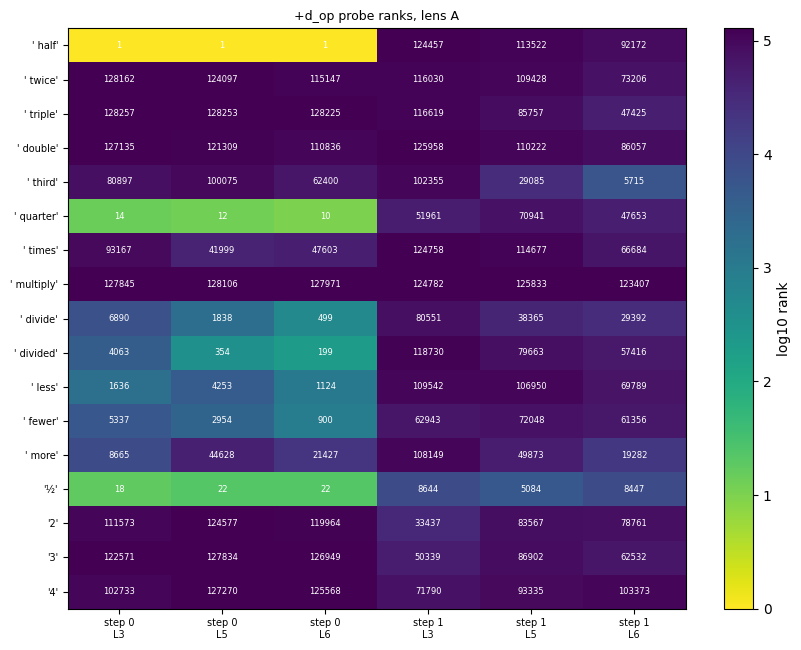

In [ ]:
# d_op probe ranks, lens A only
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

src = PROBE_DF if 'PROBE_DF' in globals() else pd.read_csv(f'{OUT_DIR}/lens_probe_ranks.csv')
SIGN = '+'   # '+' = what d_op pushes up, '-' = what it pushes down
a = src[(src.lens == 'A') & (src.direction == 'd_op') & (src.sign == SIGN)]
probes = list(dict.fromkeys(a.probe))  # keep the PROBES order
tab = a.pivot_table(index='probe', columns=['step', 'layer'], values='rank').reindex(probes)
print(f'[{SIGN}d_op probe ranks, lens A] rows = probe, cols = (step, layer); 1 = top of vocab')
print(tab.astype(int).to_string())

V_ = 128259  # vocab size (sets the colour scale)
fig, ax = plt.subplots(figsize=(1.1 * tab.shape[1] + 2, 0.3 * len(tab) + 1.5))
im = ax.imshow(np.log10(tab.values), cmap='viridis_r', aspect='auto', vmin=0, vmax=np.log10(V_))
ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels([f'step {s}\nL{l}' for s, l in tab.columns], fontsize=7)
ax.set_yticks(range(len(tab))); ax.set_yticklabels([repr(p) for p in tab.index], fontsize=7)
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        ax.text(j, i, int(tab.values[i, j]), ha='center', va='center', fontsize=6, color='w')
fig.colorbar(im, ax=ax, label='log10 rank')
ax.set_title(f'{SIGN}d_op probe ranks, lens A', fontsize=9)
plt.tight_layout(); plt.show()

J-space: 625 decompositions in 30s
     step  layer      lens       item  residual_frac  random_baseline  looks_real                                                                                                                                          top
6       0      3  identity      +d_op          0.956            0.957       False                                   half:0.66 | salv:0.34 | D:0.33 | part:0.31 | sf:0.29 | if:0.28 | Sik:0.28 | mili:0.27 | opor:0.27 | F:0.26
7       0      3  identity      -d_op          0.940            0.957       False  triple:0.66 | multiple:0.35 | Opportunity:0.35 | Th:0.34 | بير:0.33 | correlation:0.33 | n:0.30 | z:0.29 | located:0.29 | inconsistent:0.29
8       0      3  identity       +pc1          0.956            0.957       False                           of:0.07 | prefer:0.06 | erver:0.06 | twice:0.06 | two:0.06 | W:0.05 | OCR:0.05 | anan:0.05 | ev:0.05 | uffers:0.05
16      0      3  identity  raw:twice          0.951            0.957    

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing 

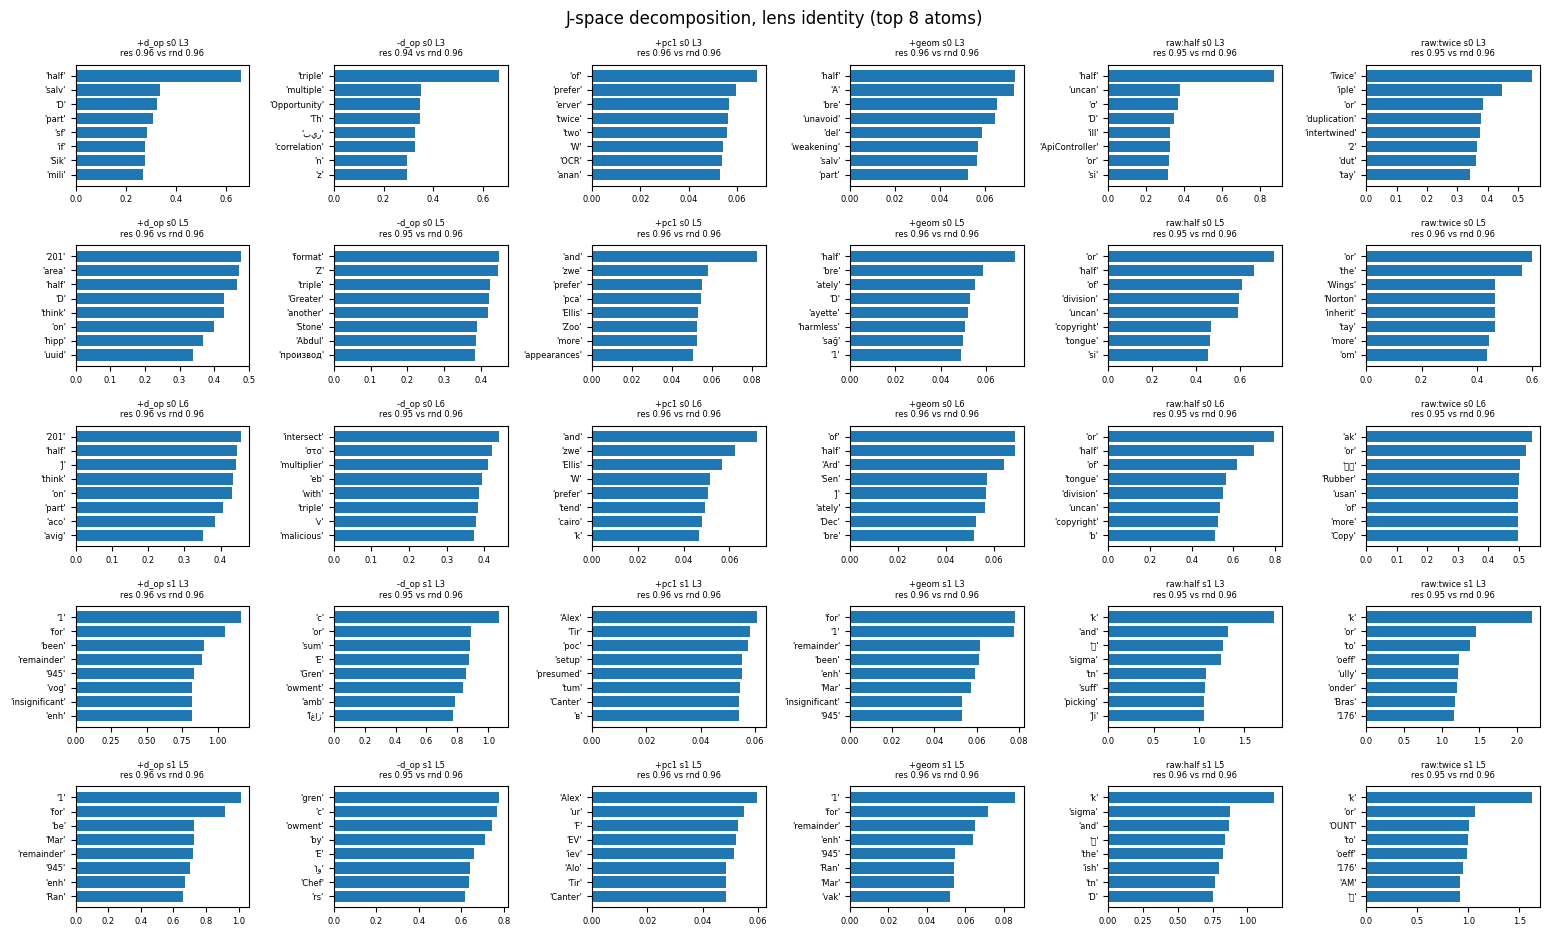

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 25308 (\N{CJK UNIFIED IDEOGRAPH-62DC}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 21672 (\N{CJK UNIFIED IDEOGRAPH-54A8}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 26124 (\N{CJK UNIFIED IDEOGRAPH-660C}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 38517 (\N{CJK UNIFIED IDE

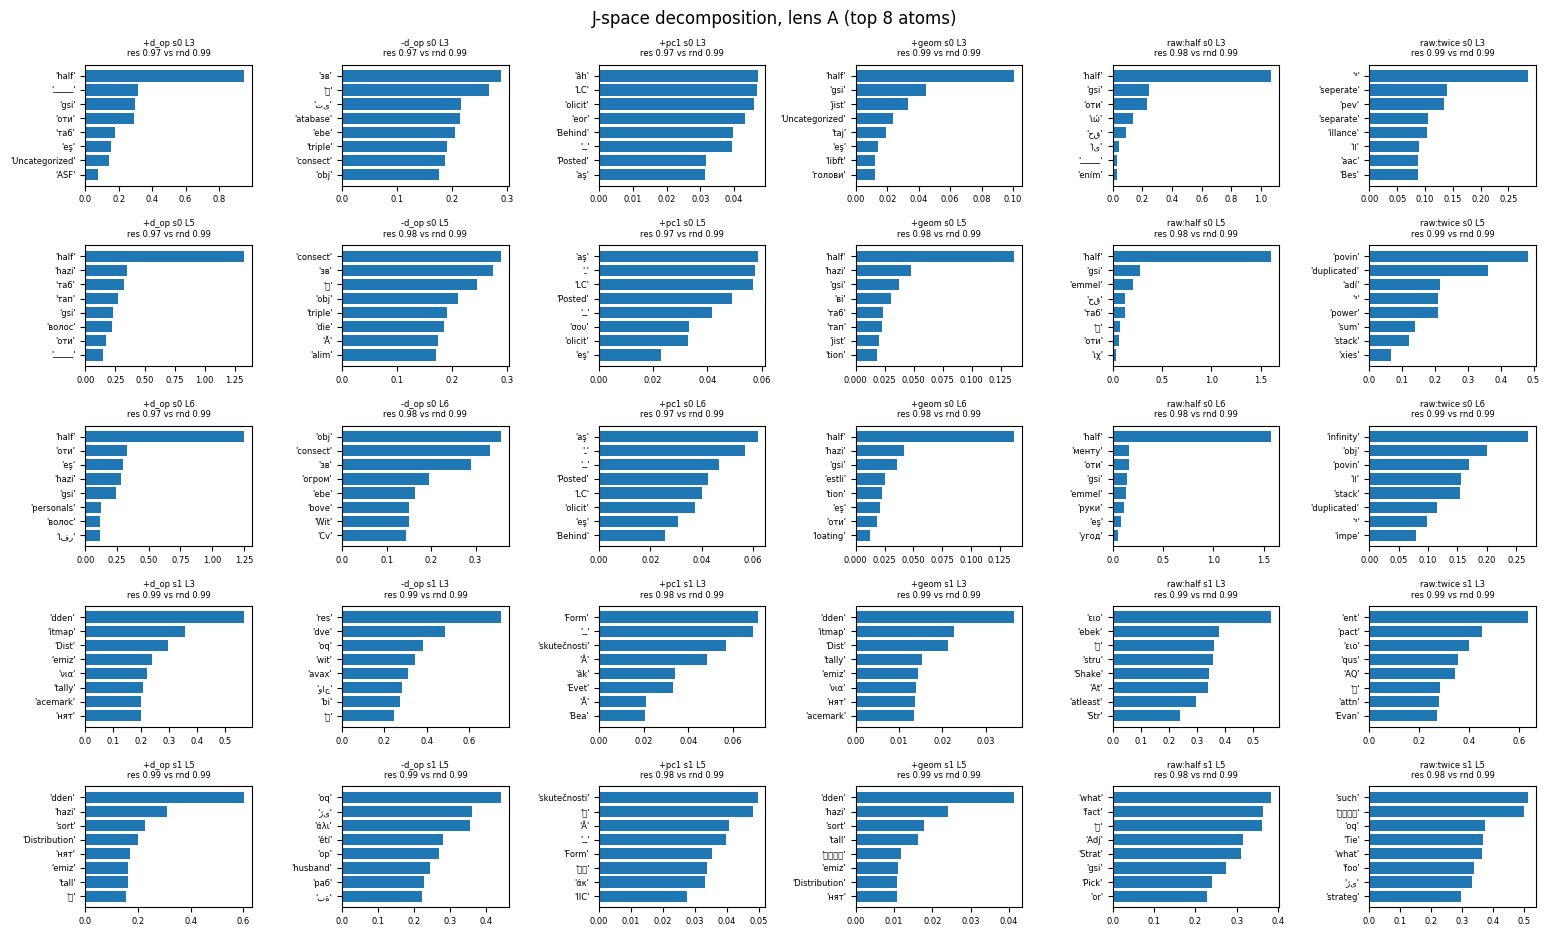

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 26124 (\N{CJK UNIFIED IDEOGRAPH-660C}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 23244 (\N{CJK UNIFIED IDEOGRAPH-5ACC}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 22475 (\N{CJK UNIFIED IDEOGRAPH-57CB}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 38517 (\N{CJK UNIFIED IDEOGRAPH-9675}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 20117 (\N{CJK UNIFI

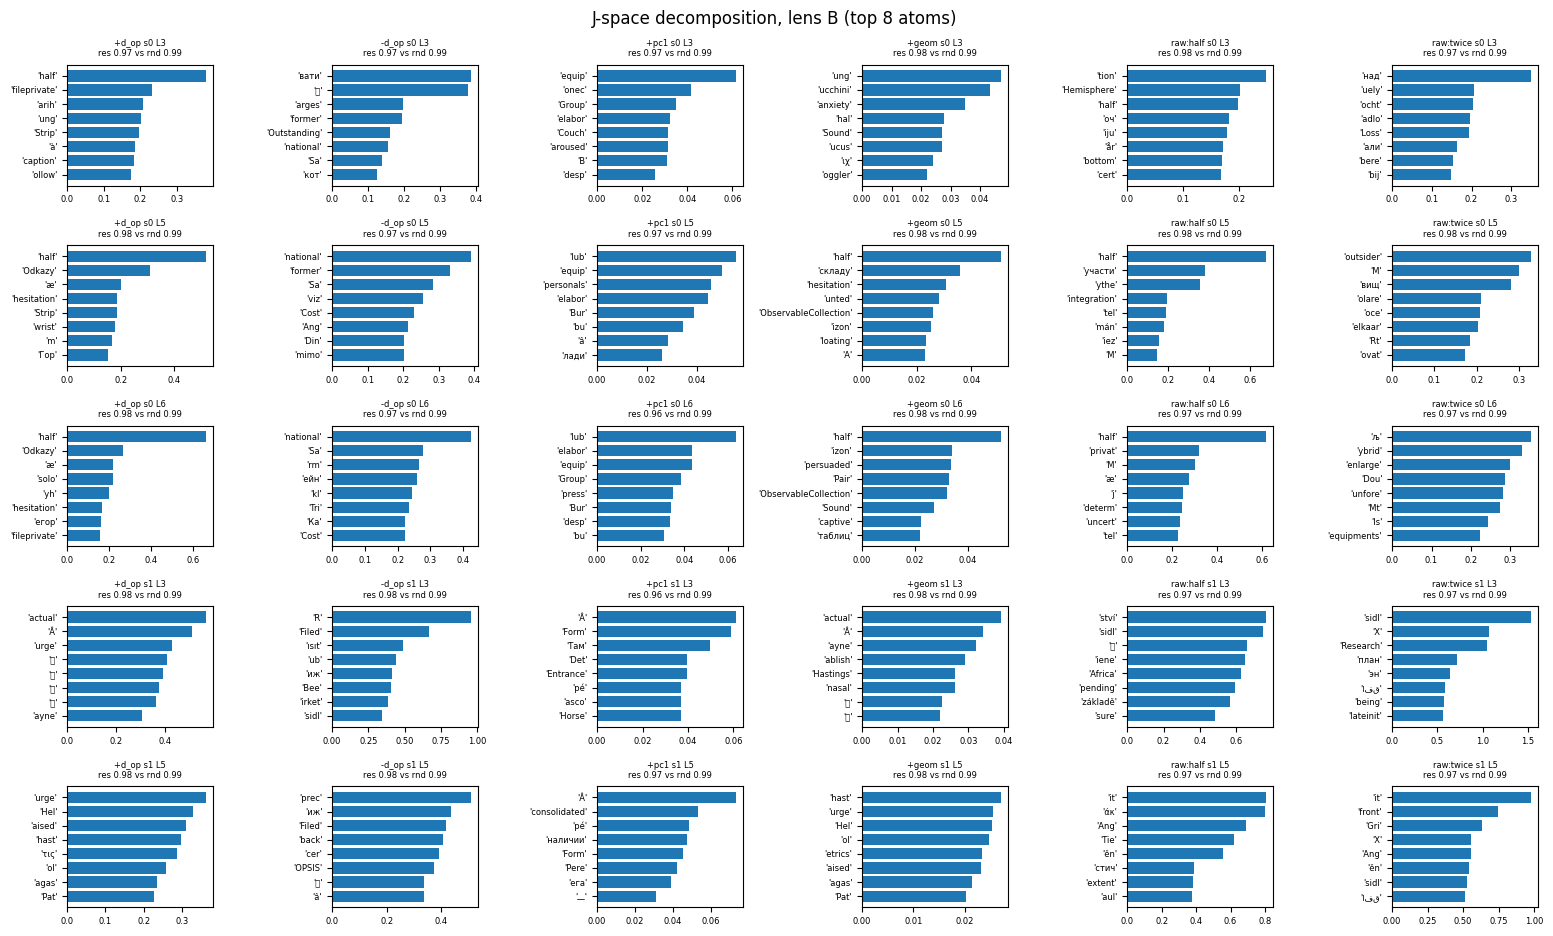

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 12373 (\N{HIRAGANA LETTER SA}) missing from font(s) D

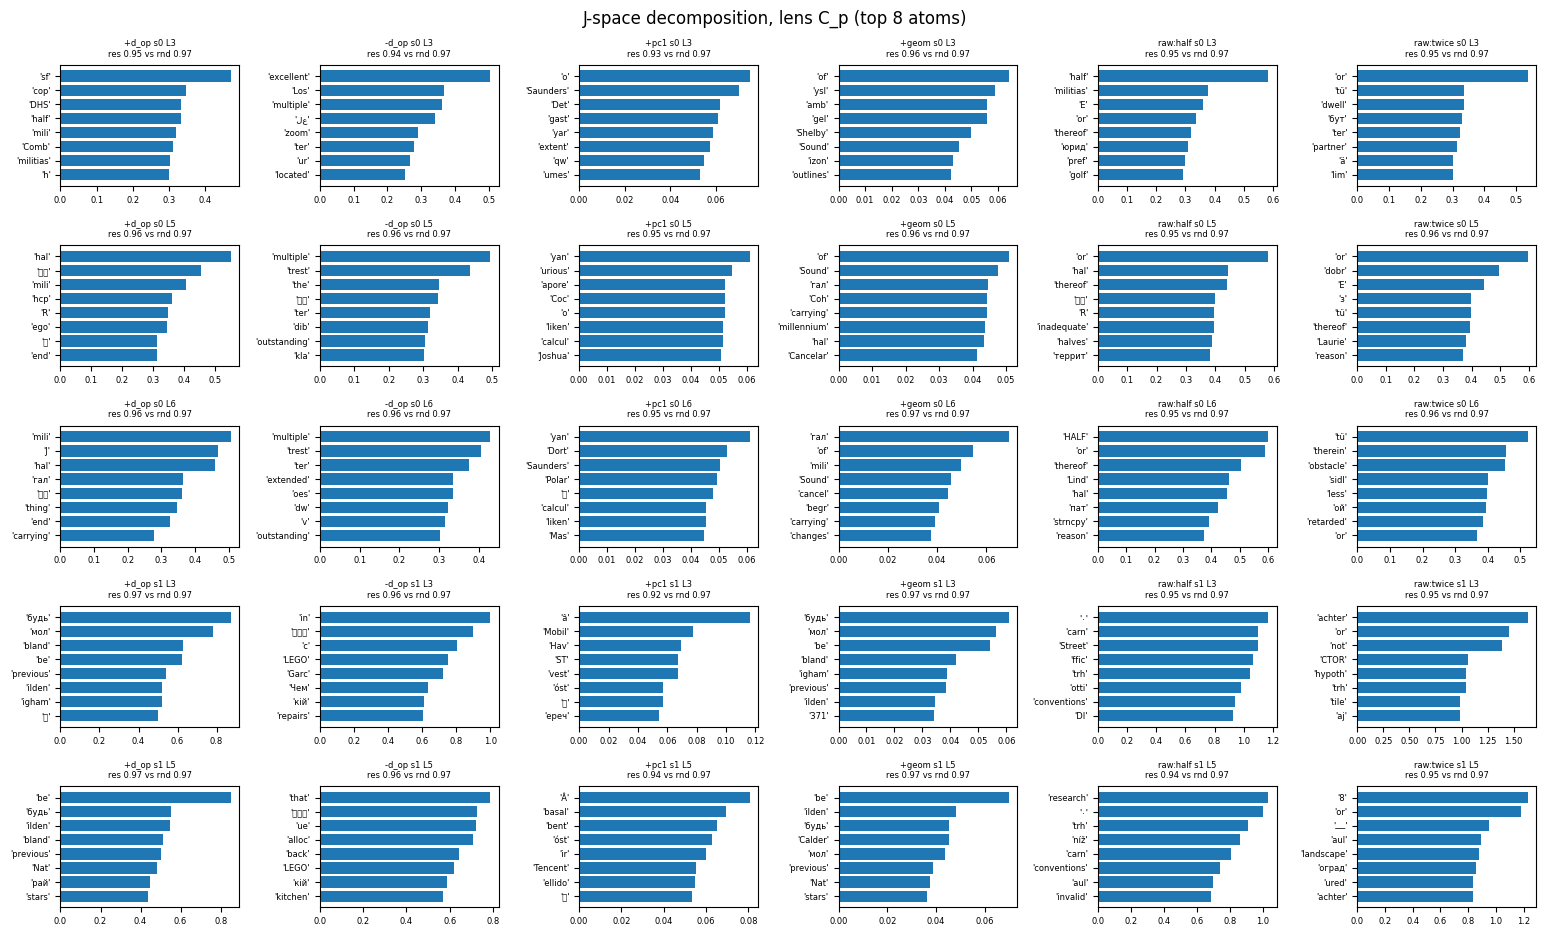

/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 50631 (\N{HANGUL SYLLABLE EOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 20035 (\N{CJK UNIFIED IDEOGRAPH-4E43}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight'); plt.show()
/tmp/ipykernel_4670/2418671691.py:74: UserWarning: Matplotlib currently does not support Devana

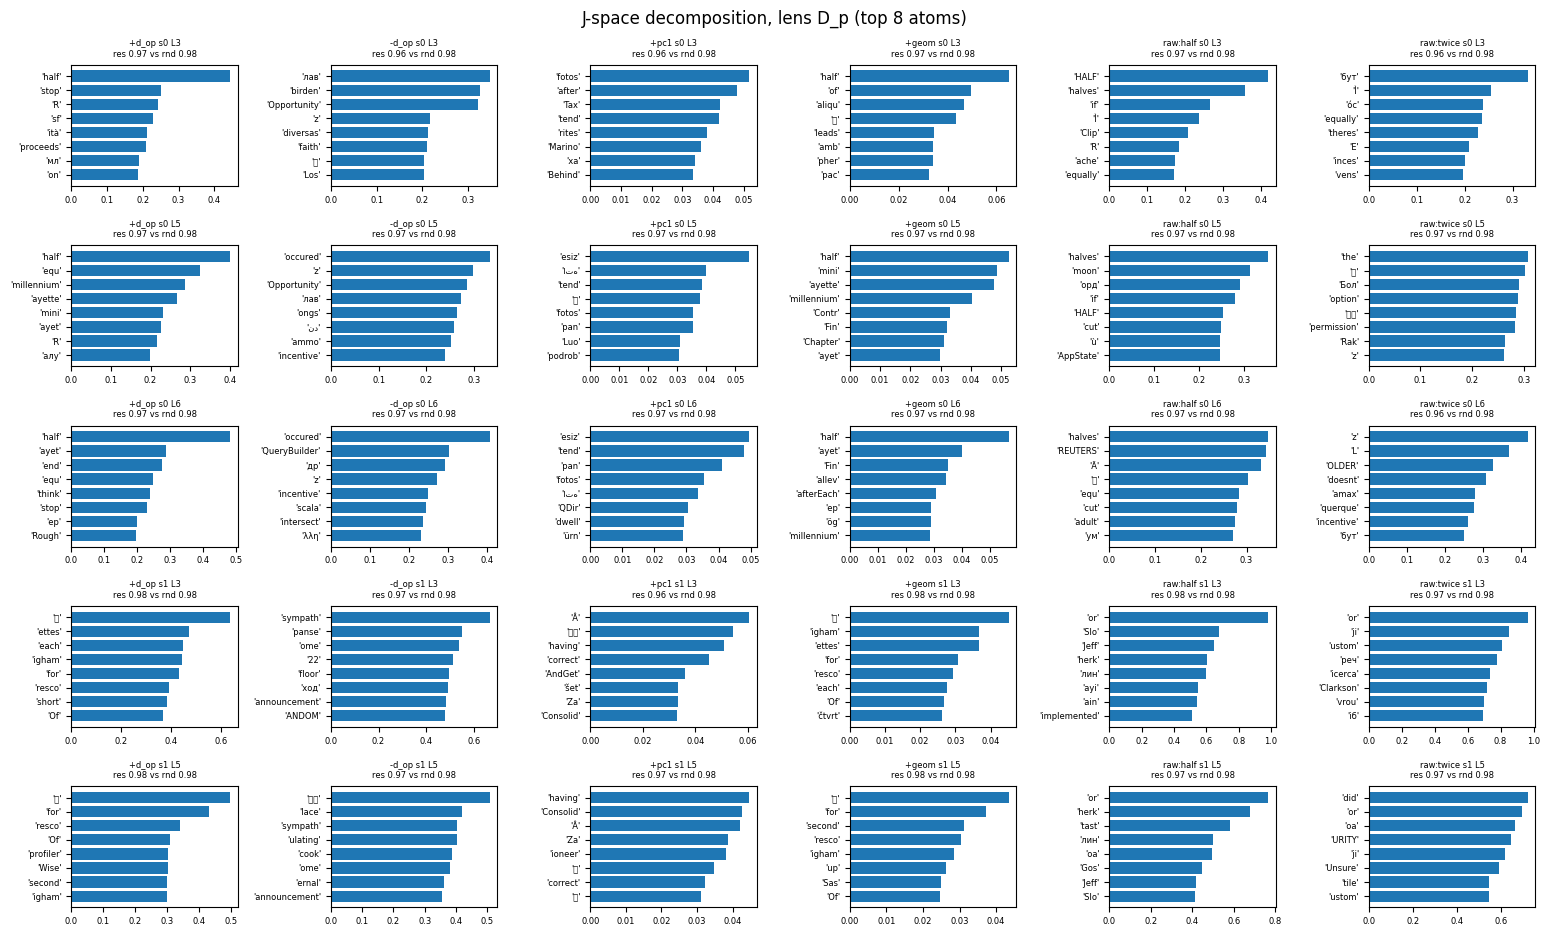


[overlap: lens-readout concepts that also appear as J-space atoms]
     step  layer      lens direction  n_lens_concepts  n_in_jspace                                                                                                                        overlap                  half_concept_atoms
0       0      3  identity     +d_op                6            2                                                                                                 {'half': 0.661, 'part': 0.309}                     {'half': 0.661}
2       0      3  identity      +pc1                9            6                                 {'uffers': 0.051, 'anan': 0.053, 'erver': 0.057, 'zwe': 0.039, 'fotos': 0.049, 'twice': 0.056}                                  {}
10      0      3         A     +d_op                7            2                                                                                                 {'half': 0.949, 'полу': 0.028}                     {'half': 0.949}
12      0   

In [ ]:
# cell: jspace
# [§3] J-space: dictionary of concept atoms per (lens, layer) = normalize((W_U[word_mask] ⊙ g) @ J_L); sparse
# non-negative decomposition (matching pursuit + NNLS refit, ported from codi_jspace_experiments_activation_patching
# cell 21) with a norm-matched random baseline. Identity lens is included as the plain logit-lens dictionary.
from scipy.optimize import nnls
_DICT, _RAND_BASE = collections.OrderedDict(), {}
WORD_IDS = torch.nonzero(WORD_MASK, as_tuple=True)[0]
def build_dictionary(lens, L, max_cached=6):
    key = (lens, L)
    if key not in _DICT:
        Jl = J(lens, L)
        A = W_U[WORD_IDS] * GAIN[None, :]
        A = A if Jl is None else A @ Jl
        _DICT[key] = (A / A.norm(dim=1, keepdim=True).clamp_min(1e-8)).half()
        while len(_DICT) > max_cached:
            _DICT.popitem(last=False)
    return _DICT[key]

def gradient_pursuit(x, atoms, k=JSPACE_K, tol=1e-4):
    x = x.to(dev).float()
    residual, active, coeffs = x.clone(), [], torch.zeros(0)
    for _ in range(k):
        sc = (atoms @ residual.half()).float()
        sc[active] = float('-inf')
        active.append(int(torch.argmax(sc)))
        A = atoms[active].float()
        c_np, _ = nnls(A.T.cpu().numpy().astype(np.float64), x.cpu().numpy().astype(np.float64))
        coeffs = torch.tensor(c_np, dtype=torch.float32, device=dev)
        residual = x - coeffs @ A
        if residual.norm() < tol:
            break
    res = [(tokenizer.decode([int(WORD_IDS[i])]), c.item(), i) for i, c in zip(active, coeffs) if c.item() > 0]
    return sorted(res, key=lambda r: -r[1]), (residual.norm() / x.norm()).item()

def random_baseline(lens, L):
    """residual_frac is scale-invariant -> one random baseline per (lens, layer), shared by every item."""
    if (lens, L) not in _RAND_BASE:
        atoms = build_dictionary(lens, L)
        g = torch.Generator().manual_seed(SEED + L)
        _RAND_BASE[(lens, L)] = float(np.mean([gradient_pursuit(torch.randn(D, generator=g), atoms)[1] for _ in range(N_RAND_CTRL)]))
    return _RAND_BASE[(lens, L)]

J_CELLS = [(0, L) for L in PROMPT_LAYERS] + LATENT_CELLS[:2]
JS, JS_ATOMS = [], {}
t0 = time.time()
for cell in J_CELLS:
    s, L = cell
    items = {f'{sg}{k}': (v if sg == '+' else -v) for k, v in directions_at(cell).items() if k != 'u_old' and v is not None for sg in '+-'}
    for w in FACTOR:  # raw residual per word (mean over train X and templates)
        hs = [resid(t, w, s, L)[split(np.where(OK[(t, w)])[0], 'train')] for t in TEMPLATES if (t, w) in KEEP]
        if hs:
            items[f'raw:{w.strip()}'] = torch.cat(hs).mean(0)
    for lens in LENS_IDS:
        atoms = build_dictionary(lens, L)
        base = random_baseline(lens, L)
        for name, x in items.items():
            concepts, rf = gradient_pursuit(x, atoms)
            JS_ATOMS[(cell, lens, name)] = concepts
            JS.append(dict(step=s, layer=L, lens=lens, item=name, residual_frac=rf, random_baseline=base,
                           looks_real=rf < base - 0.05, top=' | '.join(f'{c.strip()}:{v:.2f}' for c, v, _ in concepts[:10])))
JS = save_df(pd.DataFrame(JS), 'jspace')
print(f'J-space: {len(JS)} decompositions in {time.time() - t0:.0f}s')
print(JS[JS.item.isin(['+d_op', '-d_op', '+pc1', 'raw:half', 'raw:twice'])].round(3).to_string())

# grid plot: top 8 atoms for the key items at each J cell, one figure per lens
KEY_ITEMS = ['+d_op', '-d_op', '+pc1', '+geom', 'raw:half', 'raw:twice']
for lens in LENS_IDS:
    fig, axs = plt.subplots(len(J_CELLS), len(KEY_ITEMS), figsize=(2.6 * len(KEY_ITEMS), 1.9 * len(J_CELLS)), squeeze=False)
    for i, cell in enumerate(J_CELLS):
        for j, it in enumerate(KEY_ITEMS):
            ax = axs[i, j]; cs = JS_ATOMS.get((cell, lens, it), [])[:8]
            ax.barh(range(len(cs))[::-1], [c[1] for c in cs], color='C0')
            ax.set_yticks(range(len(cs))[::-1]); ax.set_yticklabels([repr(c[0].strip()) for c in cs], fontsize=6)
            ax.tick_params(axis='x', labelsize=6)
            r = JS[(JS.step == cell[0]) & (JS.layer == cell[1]) & (JS.lens == lens) & (JS.item == it)]
            ttl = f'{it} s{cell[0]} L{cell[1]}' + (f'\nres {r.residual_frac.iloc[0]:.2f} vs rnd {r.random_baseline.iloc[0]:.2f}' if len(r) else '')
            ax.set_title(ttl, fontsize=6)
    fig.suptitle(f'J-space decomposition, lens {lens} (top 8 atoms)')
    savefig(fig, f'jspace_grid_{lens}')

# overlap table: do the concepts §1-§2 surfaced (top-10 lens tokens of the direction, + probes ranked <= 50) appear as atoms?
rows = []
for cell in J_CELLS:
    for lens in LENS_IDS:
        for dname in ['d_op', 'pc1', 'pc2', 'pc3', 'geom']:
            for sg in '+-':
                tr = TOPS[(TOPS.step == cell[0]) & (TOPS.layer == cell[1]) & (TOPS.direction == dname) & (TOPS.lens == lens) & (TOPS.sign == sg)]
                if not len(tr):
                    continue
                lens_tokens = {tokenizer.decode([i]).strip().lower() for i in tr.top_ids.iloc[0][:10]}
                pr = PROBE_DF[(PROBE_DF.step == cell[0]) & (PROBE_DF.layer == cell[1]) & (PROBE_DF.direction == dname) & (PROBE_DF.lens == lens) & (PROBE_DF.sign == sg) & (PROBE_DF['rank'] <= 50)]
                lens_tokens |= {p.strip().lower() for p in pr.probe}
                atoms = {c.strip().lower(): v for c, v, _ in JS_ATOMS.get((cell, lens, f'{sg}{dname}'), [])}
                hit = {tkn: round(atoms[tkn], 3) for tkn in lens_tokens if tkn in atoms}
                rows.append(dict(step=cell[0], layer=cell[1], lens=lens, direction=f'{sg}{dname}', n_lens_concepts=len(lens_tokens),
                                 n_in_jspace=len(hit), overlap=hit, half_concept_atoms={a: round(v, 3) for a, v in atoms.items() if a in HALF_CONCEPT}))
OVERLAP = save_df(pd.DataFrame(rows), 'jspace_overlap')
print('\n[overlap: lens-readout concepts that also appear as J-space atoms]')
print(OVERLAP[OVERLAP.direction.isin(['+d_op', '+pc1'])].to_string())

In [ ]:
# cell: candidates
# [§4] Candidate concept directions per (step, layer) cell, built from §1-§3, plus controls. All unit vectors.
STEER_CELLS = [(0, L) for L in PROMPT_STEER_LAYERS] + LATENT_CELLS
CANDS = {}
for cell in STEER_CELLS:
    s, L = cell
    if (cell, 'fit') not in PCA:  # step-0 steering layers outside ANALYSIS_CELLS (e.g. L8, L9): fit here
        Dm, meta = diff_rows(s, L)
        X_ = Dm[torch.tensor(meta.fit.values)]
        dbar = X_.mean(0); Vt = torch.linalg.svd(X_ - dbar, full_matrices=False)[2][:N_PCS]
        sign = torch.sign(Vt @ dbar); sign[sign == 0] = 1
        PCA[(cell, 'fit')] = dict(dbar=dbar, pcs=Vt * sign[:, None])
    if cell not in GEOM:
        GEOM[cell] = dict(axis_to_half=None)
    c = {k: F.normalize(v.float(), dim=0) for k, v in directions_at(cell).items() if v is not None}
    # J-space concept direction: weighted sum of '½'-naming atoms in the decomposition of +d̄_op (best lens)
    best = None
    for lens in LENS_IDS:
        cs = [x for x in JS_ATOMS.get((cell, lens, '+d_op'), []) if x[0].strip().lower() in HALF_CONCEPT]
        wsum = sum(x[1] for x in cs)
        if cs and (best is None or wsum > best[0]):
            best = (wsum, lens, cs)
    if best:
        atoms = build_dictionary(best[1], L)
        c['jspace'] = F.normalize(sum(v * atoms[i].float() for _, v, i in best[2]).cpu(), dim=0)
    # controls: random, and a context-swap direction (T2 vs T1 with the same word), both unit
    g = torch.Generator().manual_seed(SEED * 7 + 100 * s + L)
    c['ctrl_random'] = F.normalize(torch.randn(D, generator=g), dim=0)
    if ('T1', ' twice') in KEEP and ('T2', ' twice') in KEEP:
        tr = TRAIN_IDX.values()
        ii = np.array(sorted(tr))
        c['ctrl_context'] = F.normalize((resid('T2', ' twice', s, L)[ii] - resid('T1', ' twice', s, L)[ii]).mean(0), dim=0)
    CANDS[cell] = c
    if best:
        print(f'{cell}: jspace candidate from lens {best[1]} atoms {[x[0].strip() for x in best[2]]}')
names = sorted({k for c in CANDS.values() for k in c})
print('candidates:', names)
for cell in STEER_CELLS[:3] + LATENT_CELLS[:1]:
    ks = list(CANDS[cell])
    M = torch.stack([CANDS[cell][k] for k in ks])
    print(f'\n[cosine between candidates, step {cell[0]} L{cell[1]}]')
    print(pd.DataFrame((M @ M.T).numpy(), index=ks, columns=ks).round(2).to_string())

(0, 3): jspace candidate from lens A atoms ['half']
(0, 5): jspace candidate from lens A atoms ['half']
(0, 6): jspace candidate from lens A atoms ['half', 'Half']
candidates: ['ctrl_context', 'ctrl_random', 'd_double', 'd_op', 'd_triple', 'd_twice', 'geom', 'jspace', 'pc1', 'pc2', 'pc3', 'u_old']

[cosine between candidates, step 0 L3]
              d_twice  d_triple  d_double  d_op   pc1   pc2   pc3  geom  u_old  jspace  ctrl_random  ctrl_context
d_twice          1.00      0.67      0.86  0.90 -0.28  0.12  0.11  0.70   0.28    0.13        -0.01         -0.07
d_triple         0.67      1.00      0.76  0.92  0.52  0.11  0.09  0.66   0.27    0.15        -0.05         -0.01
d_double         0.86      0.76      1.00  0.88 -0.01  0.13  0.10  0.60   0.28    0.13        -0.02         -0.06
d_op             0.90      0.92      0.88  1.00  0.15  0.13  0.11  0.74   0.30    0.15        -0.04         -0.04
pc1             -0.28      0.52     -0.01  0.15  1.00 -0.00 -0.00  0.05   0.03    0.04     

In [ ]:
# cell: steer
# [§5] Causal sweep: h <- h + alpha * |d_i| * v_hat at one (step, layer) cell, on HELD-OUT X, for every valid triple
# (so held-out words and cross-word transfer are covered automatically). d_op_loto = d̄_op refit without the prompt's
# template. |d_i| = the example's own difference norm at that cell (sets a natural scale; alpha=1 matches the oracle's size).
def dop_loto(cell, t):
    s, L = cell
    Dm, meta = diff_rows(s, L)
    m = torch.tensor((meta.fit & (meta.template != t)).values)
    return F.normalize(Dm[m].mean(0), dim=0) if m.any() else None

rows = []
t0 = time.time()
n_total = len(STEER_CELLS) * len(TRIPLES) * len(ALPHAS) * (len(names) + 1)
for cell in STEER_CELLS:
    s, L = cell
    for (t, w, h, idx) in TRIPLES:
        ii = split(idx, 'test')
        if not len(ii):
            continue
        ids, xs = IDS[(t, w)][ii], [X_ALL[i] for i in ii]
        pos = RP[(t, w)] if s == 0 else 0
        dn = (resid(t, h, s, L)[ii] - resid(t, w, s, L)[ii]).norm(dim=1, keepdim=True)
        base = evaluate(ids, xs, w, h)
        ld0 = (base['lp_t'] - base['lp_s']).mean()
        cands = dict(CANDS[cell])
        lo = dop_loto(cell, t)
        if lo is not None:
            cands['d_op_loto'] = lo
        for cname, v in cands.items():
            for a in ALPHAS:
                delta = a * dn * v[None, :]
                r = evaluate(ids, xs, w, h, [(L, s, pos, addv(delta))])
                bk = collections.Counter(r['buckets'])
                rows.append(dict(step=s, layer=L, cand=cname, alpha=a, template=t, word=w.strip(), half=h.strip(),
                                 pair=f'{w.strip()}->{h.strip()}', family=FAMILY[w], target=str(FACTOR[h]),
                                 held_out_word=w not in FIT_WORDS, n=len(xs), acc_tgt=r['acc_tgt'].mean(),
                                 m_hat=np.nanmean(r['m_hat']), m_hat_median=np.nanmedian(r['m_hat']),
                                 dLD=(r['lp_t'] - r['lp_s']).mean() - ld0, dlp_s=(r['lp_s'] - base['lp_s']).mean(),
                                 dlp_t=(r['lp_t'] - base['lp_t']).mean(), **{f'frac_{b}': bk[b] / len(xs) for b in
                                 ['target', 'source', 'x1', 'x0', 'other', 'none']}))
    print(f'cell {cell} done, {len(rows)} rows, {time.time() - t0:.0f}s elapsed')
    save_df(pd.DataFrame(rows), 'steer_sweep')  # checkpoint after every cell
STEER = save_df(pd.DataFrame(rows), 'steer_sweep')
best = STEER.groupby(['step', 'layer', 'cand', 'alpha']).acc_tgt.mean().reset_index()
print('\n[best acc_tgt over alpha, mean over all held-out triples] rows = cand, cols = (step, layer)')
print(best.groupby(['cand', 'step', 'layer']).acc_tgt.max().unstack(['step', 'layer']).round(2).to_string())

cell (0, 3) done, 1872 rows, 812s elapsed
cell (0, 5) done, 3744 rows, 1623s elapsed
cell (0, 6) done, 5616 rows, 2439s elapsed
cell (0, 8) done, 7200 rows, 3132s elapsed
cell (0, 9) done, 8784 rows, 3825s elapsed
cell (1, 3) done, 10512 rows, 4580s elapsed
cell (1, 5) done, 12240 rows, 5334s elapsed
cell (1, 6) done, 13968 rows, 6088s elapsed

[best acc_tgt over alpha, mean over all held-out triples] rows = cand, cols = (step, layer)
step             0                            1          
layer            3     5     6     8     9    3    5    6
cand                                                     
ctrl_context  0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
ctrl_random   0.00  0.00  0.00  0.00  0.00  0.0  0.0  0.0
d_double      0.46  0.39  0.31  0.07  0.03  0.0  0.0  0.0
d_op          0.55  0.31  0.27  0.02  0.00  0.0  0.0  0.0
d_op_loto     0.54  0.31  0.27  0.02  0.00  0.0  0.0  0.0
d_triple      0.26  0.12  0.11  0.03  0.01  0.0  0.0  0.0
d_twice       0.53  0.39  0.32  0.09  0

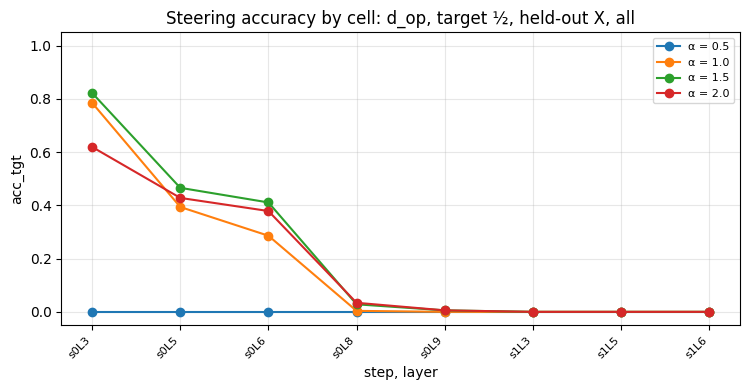

alpha       0.5   1.0   1.5   2.0
step layer                       
0    3      0.0  0.79  0.82  0.62
     5      0.0  0.39  0.47  0.43
     6      0.0  0.29  0.41  0.38
     8      0.0  0.00  0.03  0.03
     9      0.0  0.00  0.01  0.01
1    3      0.0  0.00  0.00  0.00
     5      0.0  0.00  0.00  0.00
     6      0.0  0.00  0.00  0.00


In [ ]:
# acc_tgt vs (step, layer) cell, one line per alpha
import numpy as np, pandas as pd, matplotlib.pyplot as plt

S_ = STEER if 'STEER' in globals() else pd.read_csv(f'{OUT_DIR}/steer_sweep.csv')
CAND = 'd_op'           # e.g. 'd_op', 'd_op_loto', 'pc1', 'geom', 'ctrl_random'
SUBSET = 'all'          # 'all' | 'fit_words' | 'held_out_words'
d = S_[(S_.cand == CAND) & (S_.target == '1/2')]
if SUBSET == 'fit_words':
    d = d[~d.held_out_word]
elif SUBSET == 'held_out_words':
    d = d[d.held_out_word]

cells = sorted({(int(s), int(l)) for s, l in zip(d.step, d.layer)})   # (step, layer) in order
labels = [f's{s}L{l}' for s, l in cells]
tab = d.groupby(['alpha', 'step', 'layer']).acc_tgt.mean()

fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(cells) + 2), 4))
for a in sorted(d.alpha.unique()):
    y = [tab.get((a, s, l), np.nan) for s, l in cells]
    ax.plot(range(len(cells)), y, marker='o', label=f'α = {a}')
ax.set_xticks(range(len(cells))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylim(-0.05, 1.05); ax.set_xlabel('step, layer'); ax.set_ylabel('acc_tgt')
ax.set_title(f'Steering accuracy by cell: {CAND}, target ½, held-out X, {SUBSET}')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(tab.unstack('alpha').round(2).to_string())

In [ ]:
# cell: subspace
# [§5] Subspace sufficiency / necessity at the causal cells: add only P_k d_i (sufficiency) or d_i - P_k d_i
# (necessity). Basis = orthonormalised [d̄_op, PC1..PC(k-1)] of the FIT group; k = 'full' is the oracle (d_i itself).
orc = ORACLE[ORACLE.variant == 'single'].groupby(['step', 'layer']).acc_tgt.mean()
SUB_CELLS = [c for c in STEER_CELLS if orc.get(c, 0) >= 0.5] or [(0, L) for L in PROMPT_LAYERS]
print('subspace cells (oracle acc >= 0.5):', SUB_CELLS)
rows = []
t0 = time.time()
for cell in SUB_CELLS:
    s, L = cell
    P = PCA[(cell, 'fit')]
    basis_full = torch.linalg.qr(torch.cat([F.normalize(P['dbar'], dim=0)[None], P['pcs']]).T).Q.T
    for (t, w, h, idx) in TRIPLES:
        ii = split(idx, 'test')
        if not len(ii):
            continue
        ids, xs = IDS[(t, w)][ii], [X_ALL[i] for i in ii]
        pos = RP[(t, w)] if s == 0 else 0
        d = resid(t, h, s, L)[ii] - resid(t, w, s, L)[ii]
        for k in SUBSPACE_KS + ['full']:
            if k == 'full':
                modes = [('full', d)]
            else:
                if k > len(basis_full):
                    continue
                Bk = basis_full[:k]
                pd_ = (d @ Bk.T) @ Bk
                modes = [('sufficiency', pd_), ('necessity', d - pd_)]
            for mode, delta in modes:
                r = evaluate(ids, xs, w, h, [(L, s, pos, addv(delta))])
                rows.append(dict(step=s, layer=L, k=str(k), mode=mode, template=t, pair=f'{w.strip()}->{h.strip()}', family=FAMILY[w],
                                 held_out_word=w not in FIT_WORDS, acc_tgt=r['acc_tgt'].mean(), m_hat=np.nanmean(r['m_hat']),
                                 frac_norm2=((delta.norm(dim=1) ** 2).sum() / (d.norm(dim=1) ** 2).sum()).item()))
    save_df(pd.DataFrame(rows), 'subspace')
SUB = save_df(pd.DataFrame(rows), 'subspace')
print(f'subspace: {len(SUB)} rows in {time.time() - t0:.0f}s')
print(SUB.groupby(['step', 'layer', 'mode', 'k']).acc_tgt.mean().unstack('k').round(2).to_string())

subspace cells (oracle acc >= 0.5): [(0, 3), (0, 5), (0, 6)]
subspace: 1404 rows in 596s
k                          1    10     2    20     3     5  full
step layer mode                                                 
0    3     full          NaN   NaN   NaN   NaN   NaN   NaN  0.86
           necessity    0.05  0.00  0.00  0.00  0.00  0.00   NaN
           sufficiency  0.29  0.38  0.37  0.40  0.37  0.37   NaN
     5     full          NaN   NaN   NaN   NaN   NaN   NaN  0.71
           necessity    0.00  0.00  0.00  0.00  0.00  0.00   NaN
           sufficiency  0.19  0.32  0.32  0.32  0.32  0.32   NaN
     6     full          NaN   NaN   NaN   NaN   NaN   NaN  0.54
           necessity    0.00  0.00  0.00  0.00  0.00  0.00   NaN
           sufficiency  0.13  0.28  0.28  0.28  0.28  0.27   NaN


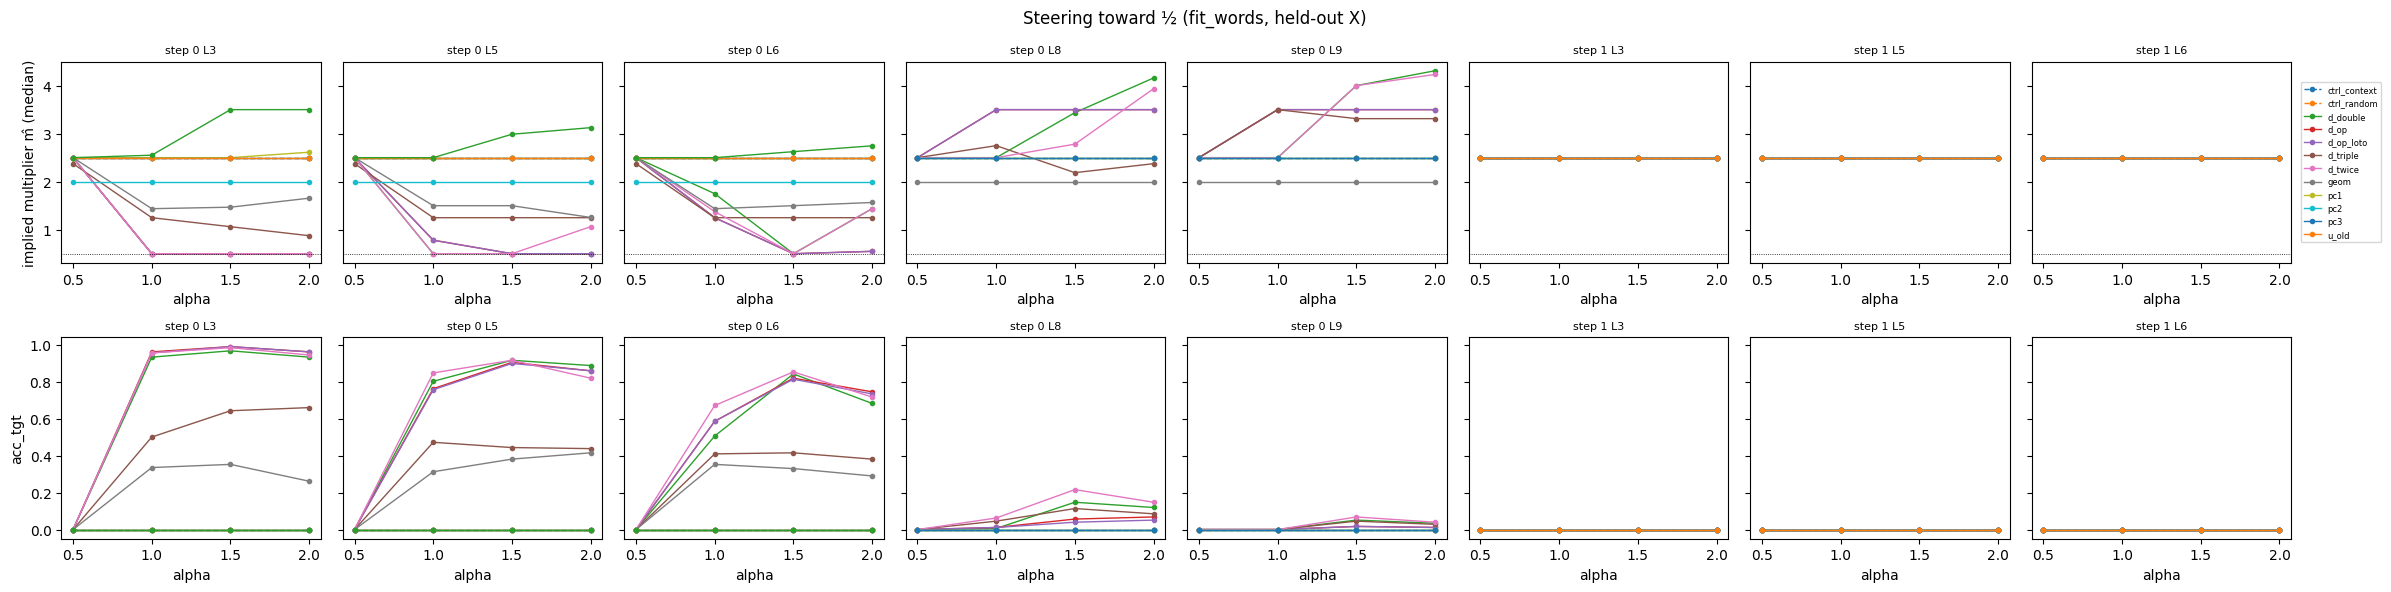

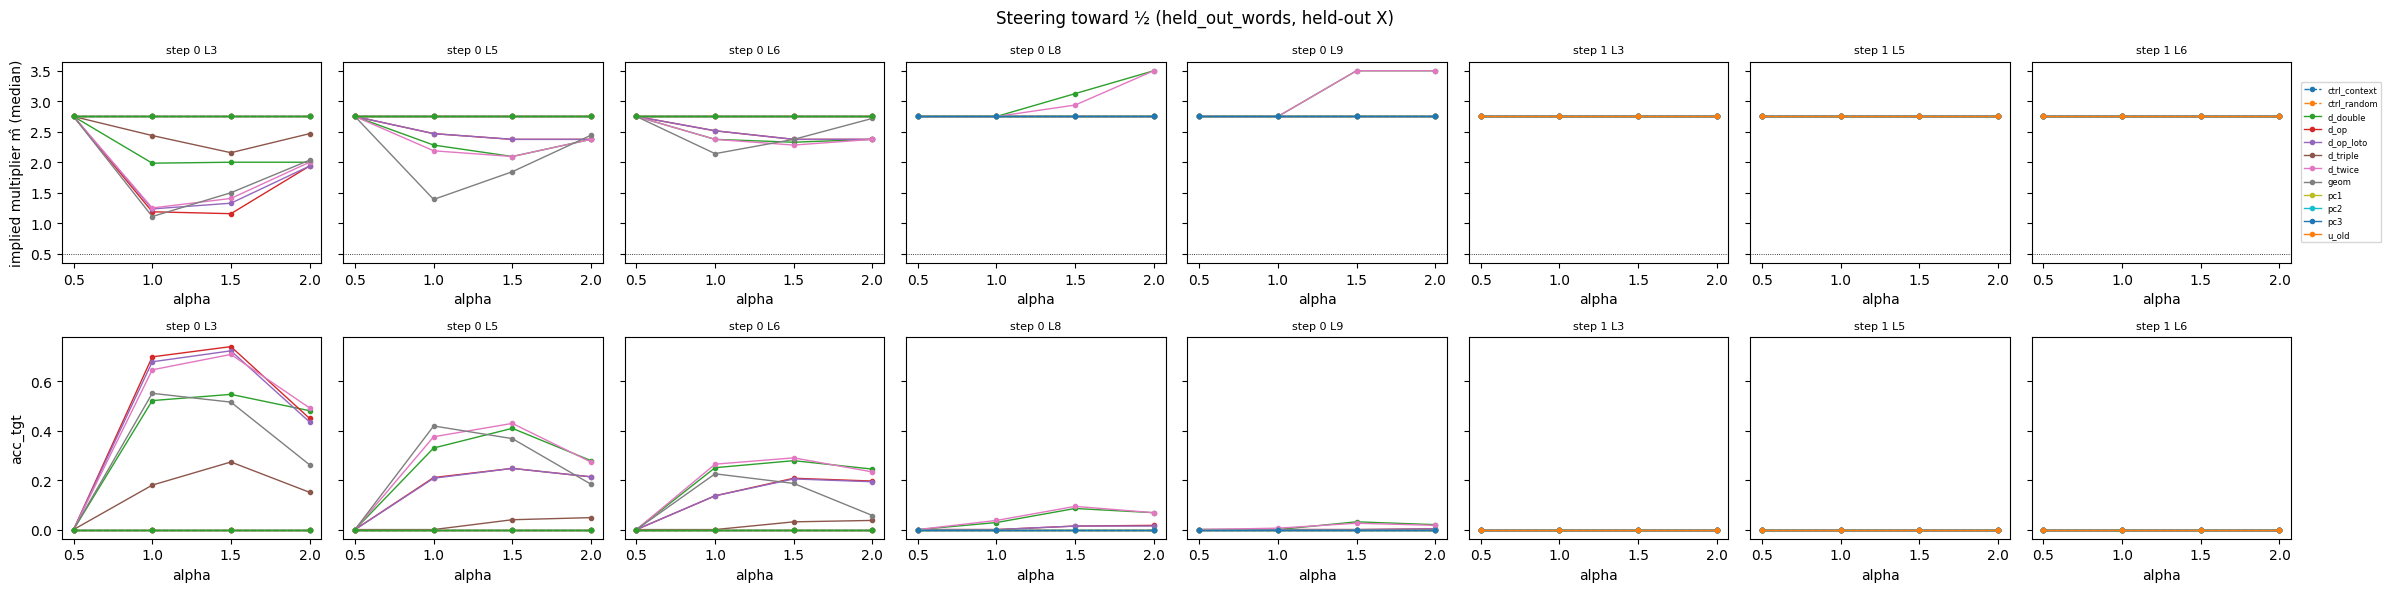

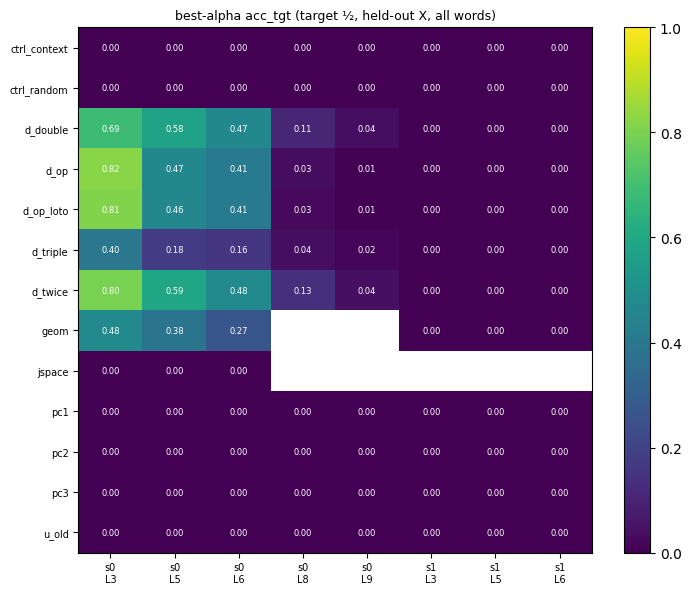

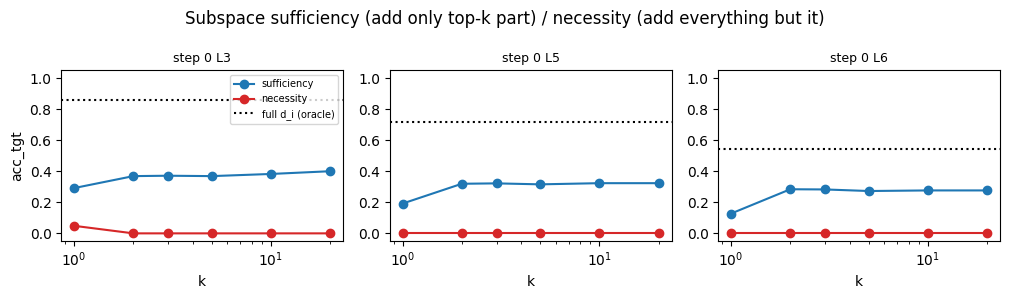

In [ ]:
# cell: steer_plots
# m̂ vs alpha per candidate (median over held-out triples), one panel per steering cell; controls dashed.
CTRL = {'ctrl_random', 'ctrl_context'}
for split_name, sel in [('fit_words', ~STEER.held_out_word), ('held_out_words', STEER.held_out_word)]:
    S_ = STEER[sel & (STEER.target == '1/2')]
    if not len(S_):
        continue
    fig, axs = plt.subplots(2, len(STEER_CELLS), figsize=(3 * len(STEER_CELLS), 6), squeeze=False, sharey='row')
    for j, cell in enumerate(STEER_CELLS):
        sub = S_[(S_.step == cell[0]) & (S_.layer == cell[1])]
        for i, (metric, lab) in enumerate([('m_hat_median', 'implied multiplier m̂ (median)'), ('acc_tgt', 'acc_tgt')]):
            ax = axs[i, j]
            for cname, g in sub.groupby('cand'):
                gg = g.groupby('alpha')[metric].mean()
                ax.plot(gg.index, gg.values, marker='.', ls='--' if cname in CTRL else '-', lw=1, label=cname)
            if metric == 'm_hat_median':
                ax.axhline(0.5, color='k', lw=0.6, ls=':')
            ax.set_title(f'step {cell[0]} L{cell[1]}', fontsize=8); ax.set_xlabel('alpha')
            if j == 0: ax.set_ylabel(lab)
    axs[0, -1].legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5))
    fig.suptitle(f'Steering toward ½ ({split_name}, held-out X)')
    savefig(fig, f'steer_mhat_{split_name}')

best = STEER[STEER.target == '1/2'].groupby(['cand', 'step', 'layer', 'alpha']).acc_tgt.mean().groupby(['cand', 'step', 'layer']).max().unstack(['step', 'layer'])
fig, ax = plt.subplots(figsize=(1 + 0.8 * best.shape[1], 0.35 * best.shape[0] + 1.5))
im = ax.imshow(best.values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
ax.set_xticks(range(best.shape[1])); ax.set_xticklabels([f's{a}\nL{b}' for a, b in best.columns], fontsize=7)
ax.set_yticks(range(best.shape[0])); ax.set_yticklabels(best.index, fontsize=7)
for i in range(best.shape[0]):
    for j in range(best.shape[1]):
        ax.text(j, i, f'{best.values[i, j]:.2f}', ha='center', va='center', fontsize=6, color='w')
fig.colorbar(im, ax=ax); ax.set_title('best-alpha acc_tgt (target ½, held-out X, all words)', fontsize=9)
savefig(fig, 'steer_best_alpha')

fig, axs = plt.subplots(1, len(SUB_CELLS), figsize=(3.4 * len(SUB_CELLS), 3), squeeze=False)
for ax, cell in zip(axs[0], SUB_CELLS):
    sub = SUB[(SUB.step == cell[0]) & (SUB.layer == cell[1])]
    for mode, c in [('sufficiency', 'C0'), ('necessity', 'C3')]:
        g = sub[sub['mode'] == mode].groupby('k').acc_tgt.mean()
        ks = [k for k in map(str, SUBSPACE_KS) if k in g.index]
        ax.plot([int(k) for k in ks], g[ks].values, marker='o', color=c, label=mode)
    full = sub[sub['mode'] == 'full'].acc_tgt.mean()
    ax.axhline(full, color='k', ls=':', label='full d_i (oracle)'); ax.set_xscale('log')
    ax.set_title(f'step {cell[0]} L{cell[1]}', fontsize=9); ax.set_xlabel('k'); ax.set_ylim(-0.05, 1.05)
axs[0, 0].set_ylabel('acc_tgt'); axs[0, 0].legend(fontsize=7)
fig.suptitle('Subspace sufficiency (add only top-k part) / necessity (add everything but it)')
savefig(fig, 'subspace_k')

In [ ]:
# cell: export
def md_table(t):
    t = t.reset_index() if not isinstance(t.index, pd.RangeIndex) else t
    lines = ['| ' + ' | '.join(map(str, t.columns)) + ' |', '|' + '---|' * len(t.columns)]
    for _, r in t.iterrows():
        lines.append('| ' + ' | '.join('' if (isinstance(v, float) and np.isnan(v)) else (f'{v:.3f}' if isinstance(v, float) else str(v).replace('|', '/')) for v in r.values) + ' |')
    return '\n'.join(lines)

rep = ['# steer_to_half_concepts: automatic results\n', f'Lens sources: {LENS_PROV}\n', f'Prefix: {tokenizer.decode(PREFIX)!r}\n',
       '## Clean accuracy\n', md_table(ACC.pivot_table(index='word', columns='template', values='acc').round(3)),
       '\n## Oracle map (acc_tgt, mean over triples)\n', md_table(ORACLE[ORACLE.variant == 'single'].pivot_table(index='step', columns='layer', values='acc_tgt').round(3)),
       f'\nLATENT_CELLS: {LATENT_CELLS}\n',
       '\n## Shared fraction (half_all)\n', md_table(SHARED[SHARED.group == 'half_all'].pivot_table(index='step', columns='layer', values='shared').round(3)),
       '\n## PCA explained / d̄ relation\n', md_table(EXPL.round(3)),
       '\n## PC labels (group all)\n', md_table(PC_LABELS.round(3)),
       '\n## Geometry\n', md_table(GEOM_DF.round(3)),
       '\n## Principal angles\n', md_table(ANG.round(3)),
       '\n## Lens top tokens (d_op, pc1)\n', md_table(TOPS[TOPS.direction.isin(['d_op', 'pc1'])].drop(columns='top_ids')),
       '\n## J-space (key items)\n', md_table(JS[JS.item.isin(['+d_op', '-d_op', '+pc1', 'raw:half', 'raw:twice'])].round(3)),
       '\n## Steering: best-alpha acc_tgt (target ½)\n', md_table(best.round(3)),
       '\n## Subspace\n', md_table(SUB.groupby(['step', 'layer', 'mode', 'k']).acc_tgt.mean().unstack('k').round(3))]
open(f'{OUT_DIR}/steer_to_half_concepts_results_auto.md', 'w').write('\n'.join(rep))
print('saved to', OUT_DIR, ':', sorted(os.listdir(OUT_DIR)))
if wandb_run is not None:
    art = wandb.Artifact('steer-half-concepts-results', type='results')
    for f in os.listdir(OUT_DIR):
        if f.endswith('.csv') or f.endswith('.md'):
            art.add_file(f'{OUT_DIR}/{f}')
    wandb_run.log_artifact(art)
    if SAVE_CAPTURE_ARTIFACT:
        cap_path = '/content/steer_half_resid.pt'
        torch.save({'X_ALL': X_ALL, 'SPAN': SPAN, 'CAP': {k: {kk: vv.half() for kk, vv in v.items()} for k, v in CAP.items()},
                    'CLEAN_PRED': {k: v['pred'] for k, v in CLEAN.items()}}, cap_path)
        art2 = wandb.Artifact('steer-half-resid', type='activations'); art2.add_file(cap_path)
        wandb_run.log_artifact(art2)
    wandb_run.finish()

saved to /content/drive/MyDrive/jlens_checkpoints/codi_llama3.2-1b/compare/steer_to_half/concepts : ['figs', 'geometry.csv', 'jspace.csv', 'jspace_overlap.csv', 'lens_probe_ranks.csv', 'lens_top_tokens.csv', 'oracle_map.csv', 'pca_explained.csv', 'pca_labels.csv', 'principal_angles.csv', 'principal_angles_cells.csv', 'shared_fraction.csv', 'steer_sweep.csv', 'steer_to_half_concepts_results_auto.md', 'subspace.csv']
